# To-dos


- Check applicant quality
    - We might not find a direct effect of deal quality on the number of applications, but it might drive the number of high quality applications
- The effect of quality might not be significant when the deal is 'good enough', but it might be significant when the deal is 'bad'
    - Split the ratings into categories, and try to predict 'bad' vs. 'good enough' deals

----------

In [ ]:
from src.barter.regression_models import create_regression_runner
from src.analysis.engine import AnalysisEnvironment
from src.utils import interactive_regression_results_selector, simple_dashboard
import pandas as pd
import numpy as np
from scipy.stats.mstats import winsorize
from src.analysis.model_evaluation import ExperimentRegistry, interactive_model_viewer

In [2]:
# Setup
env = AnalysisEnvironment(active_analysis='barter_deals')

# Load everything
final_df, og_df = env.load_data()
pm, prompt_map = env.load_prompts(prompt_subfolder='sandbox/BARTER_DEALS')

Loading files for analysis barter_deals
🐢 Running full processing pipeline...
Finished loading experiment data
⚠️ Warning: 2 rows from input data are missing LLM results.
Found 8 experimental trials contaminated by garbage output.
Found 2 different scale sizes: [np.int64(4), np.int64(5)]
  Processed 17998 rows with scale_size=4
  Processed 7434 rows with scale_size=5
Computing entropy for 2 different scale sizes: [np.int64(4), np.int64(5)]
  Processed 17998 rows with scale_size=4
  Processed 7434 rows with scale_size=5
PromptManager initialized with folder: ..\prompts\PromptSuites\sandbox\BARTER_DEALS
Scanning 4 suites from ..\prompts\PromptSuites\sandbox\BARTER_DEALS...
Loaded 4 PromptSuites


# Data cleaning

We consider a number of filtering approaches. Content type is a strong predictor, but some have too few observations to obtain a stable parameter estimate. E.g., Finance and Photography have only 15 and 5 observations respectively, and with a coefficient of $\approx -23$, in a log model their coefficient is effectively zero. Since they have near-zero applications in the entire dataset, we waste degrees of freedom trying to fit tiny noisy groups. We suggest a to filter category size to only include ones that have "signal" in their observations. 


- Remove obs with 0 applications

There are 'dead deals', where they have zero applications but are well-written. They have never been online at all, artificially inflating the zero-category with structural error (good deals that have no applications, while we know that good deals will get more applications). We remove the deals with 0 applications $n=865$, while retaining sufficient number of deals with 0 applications after 7 days $n=1650$


- Deals with a significant number of applications but no applications after 7 days

Some deals have no applications after 7 days, but a high total applications count. I observed that often these are good deals, but have no applications after 7 days for different reasons. The apps after 7 days variable is created using a specific starting date within in the database, but there is no 'clean' variable that measures when it actually went live. It could have been put live weeks after being created, so it garnered applications later than the initial seven-day period. Therefore, we remove observations where this difference is too big, indicating that the applications after 7 days is not representative of its actual performance. 


- Remove archived deals

We remove archived deals because they likely have never been put live 

- Average duplicate deal texts

We have deals that are identical, but with different numbers of applications. We take the average to remove some of the noise. 

- Partner filters

We remove $partner\_id=85$ because they are deals posted by Barter, they are part of Barter campaigns not the regular partner deals. 

- winsorizing (cap the variable at the 9xth percentile)

In count data (especially social media or job posts), "viral" outliers can distort the mean and variance. A single post with 1,000 applications (due to luck) adds massive noise.


In [25]:
import pandas as pd
from functools import wraps

# --- Logging Tool (Decorator) ---


def log_step(func):
    """
    A decorator that prints the shape of the dataframe before and after 
    a function execution, effectively tracking data loss.
    """
    @wraps(func)
    def wrapper(df, *args, **kwargs):
        start_len = len(df)
        result_df = func(df, *args, **kwargs)
        end_len = len(result_df)
        diff = start_len - end_len
        pct_lost = (diff / start_len * 100) if start_len > 0 else 0

        print(f"[{func.__name__:<25}] Start: {start_len:<6} | End: {end_len:<6} | Dropped: {diff:<5} ({pct_lost:.1f}%)")
        return result_df
    return wrapper

# --- Atomic Cleaning Steps ---


@log_step
def filter_incomplete_weeks(df):
    cutoff_date = df['created_at'].max() - pd.Timedelta(days=14)
    return df[df['created_at'] < cutoff_date].copy()


@log_step
def filter_low_n_categories(df, min_observations=50):
    counts = df['first_content_type'].value_counts()
    valid_categories = counts[counts >= min_observations].index
    return df[df['first_content_type'].isin(valid_categories)].copy()


@log_step
def filter_zero_applications(df):
    return df[df['applicants_applications_count'] > 0].copy()


@log_step
def filter_dead_high_volume_deals(df, floor=30):
    condition = (df['applicants_applications_count'] >
                 floor) & (df['apps_after_7_days'] == 0)
    return df[~condition].copy()


@log_step
def filter_archived(df):
    return df[df['status'] != 'archived'].copy()


@log_step
def filter_partners(df, partner_ids_to_remove):
    return df[~df['partner_id'].isin(partner_ids_to_remove)].copy()


@log_step
def filter_languages(df, languages_to_remove):
    return df[~df['deal_language'].isin(languages_to_remove)].copy()


@log_step
def filter_for_deal_value(df, min_deal_value):
    return df[df.deal_value > min_deal_value]


@log_step
def min_apps(df, min_apps_after_7_days):
    # Sets a minimum for the KPI, with the idea of modelling the non-zero deals. Set to -1 to ignore
    return df[df['apps_after_7_days'] > min_apps_after_7_days]

@log_step
def max_follower_requirement(df, max_follower_requirement):
    return df[df['min_social_media_followers'] < max_follower_requirement]

@log_step
def log_transform_cols(df, cols):
    """
    Applies log1p transformation to specified columns.
    Creates new columns with 'log_' prefix to preserve original data.
    """
    # Create a copy to avoid SettingWithCopyWarning on slice
    df = df.copy()

    for col in cols:
        if col in df.columns:
            # log1p calculates log(1 + x), safe for 0 values
            df[f'log_{col}'] = np.log1p(df[col])
        else:
            print(
                f"⚠️ Warning: Column '{col}' not found, skipping log transform.")

    return df

# Note: Winsorizing is a transformation, not a filter, so it usually doesn't change row count.
# We can skip the @log_step here or create a different logger for transformations.


def apply_transformations(df):
    df = df.copy()
    # Apply winsorization logic here (assuming function exists)
    # df['apps_after_7_days_clean'] = ...

    df['social_requirement_type_id'] = df['social_requirement_type_id'].astype(
        int).astype(str)
    return df

# --- The Pipeline ---


def run_cleaning_pipeline(raw_df, config):
    print(f"{'STEP':<30} {'START':<6}   {'END':<6}   {'DROPPED':<5} {'% LOSS'}")
    print("-" * 75)

    clean_df = (
        raw_df
        .pipe(filter_incomplete_weeks)
        .pipe(filter_low_n_categories, min_observations=config["MIN_CATEGORY_OBSERVATIONS"])
        .pipe(filter_zero_applications)
        .pipe(filter_dead_high_volume_deals, floor=config["diff_total_apps_7_days_floor"])
        .pipe(filter_archived)
        .pipe(max_follower_requirement, max_follower_requirement=config['max_follower_requirement'])
        .pipe(min_apps, min_apps_after_7_days=config['min_apps_after_7_days'])
        .pipe(filter_partners, partner_ids_to_remove=config["PARTNER_IDS_TO_REMOVE"])
        .pipe(filter_languages, languages_to_remove=config["DEAL_LANGUAGES_TO_REMOVE"])
        .pipe(filter_for_deal_value, min_deal_value=config["MIN_DEAL_VALUE"])
        .pipe(log_transform_cols, cols=config['LOG_TRANSFORM_COLS'])
    )

    # Apply non-filtering transformations at the end (usually these don't drop rows)
    # clean_df = apply_transformations(clean_df)

    return clean_df

In [33]:
# # 1. Define a minimum threshold (e.g., 50 observations)
# def filter_low_n_categories(df, MIN_OBSERVATIONS=50):

#     # 2. Count observations per category
#     counts = df['first_content_type'].value_counts()

#     # 3. Identify valid categories
#     valid_categories = counts[counts >= MIN_OBSERVATIONS].index.tolist()

#     print(f"Keeping {len(valid_categories)} categories: {valid_categories}")
#     print(f"Dropping: {counts[counts < MIN_OBSERVATIONS].index.tolist()}")

#     # 4. Filter the dataframe
#     # Only keep rows where the content type is in our valid list
#     return df[df['first_content_type'].isin(valid_categories)].copy()


# def data_cleaning(ratings_df,
#                   MIN_CATEGORY_OBSERVATIONS: int = 50,
#                   PARTNER_IDS_TO_REMOVE: list = [85, 4],
#                   DEAL_LANGUAGES_TO_REMOVE: list = ['en', 'nl', 'de'],
#                   diff_total_apps_7_days_floor=30
#                   ):
#     df = ratings_df.copy()

#     # Remove incomplete weeks (a deal needs to be online for 7 days in order for the KPI to be meaningful)
#     ## Cut off the last 7 days of data completely to avoid this censoring bias
#     cutoff_date = df['created_at'].max() - pd.Timedelta(days=14)
#     df = df[df['created_at'] < cutoff_date]


#     # Remove categories with low number of observations (important if it is added as predictor)
#     df = filter_low_n_categories(df, MIN_CATEGORY_OBSERVATIONS)

#     # Remove obs with 0 applications
#     df = df[df['applicants_applications_count'] > 0]

#     # Keep rows that are NOT (High Volume AND Dead)
#     ## Deals with a significant number of applications but no applications after 7 days
#     condition_to_remove = (df['applicants_applications_count'] > diff_total_apps_7_days_floor) & (df['apps_after_7_days'] == 0)
#     df = df[~condition_to_remove]

#     # df = df[~(df['applicants_applications_count'] >
#     #           diff_total_apps_7_days_floor) & (df['apps_after_7_days'] > 0)]

#     # Remove archived deals (never have been put live)
#     df = df[df['status'] != 'archived']

#     # Filter specific partners
#     df = df[~df.partner_id.isin(PARTNER_IDS_TO_REMOVE)]

#     # Filter specific Language categories
#     df = df[~df.deal_language.isin(DEAL_LANGUAGES_TO_REMOVE)]

#     # # Clip the top 1% of outliers to reduce variance from 'viral luck'
#     df['apps_after_7_days_clean'] = winsorize(
#         df['apps_after_7_days'], limits=[0, 0.01])

#     df['social_requirement_type_id'] = df['social_requirement_type_id'].astype(
#         int).astype(str)

#     print(f"Went from {len(ratings_df)} observations to {len(df)} observations")


#     return df

In [26]:
# 1. Define your configuration dictionary
cleaning_config = {
    "MIN_CATEGORY_OBSERVATIONS": 200,
    "PARTNER_IDS_TO_REMOVE": [85, 4],
    "DEAL_LANGUAGES_TO_REMOVE": ['de'],
    "diff_total_apps_7_days_floor": 10,
    'min_apps_after_7_days': -1,
    "MIN_DEAL_VALUE": 0,
    "LOG_TRANSFORM_COLS": ['deal_value'],
    "max_follower_requirement": 25000
}


model_df = run_cleaning_pipeline(final_df, cleaning_config)
og_model_df = run_cleaning_pipeline(og_df, cleaning_config)
# 2. Pass it to the function using ** unpacking
# model_df = data_cleaning(final_df, **cleaning_config)
# og_model_df = data_cleaning(og_df, **cleaning_config)

STEP                           START    END      DROPPED % LOSS
---------------------------------------------------------------------------
[filter_incomplete_weeks  ] Start: 25403  | End: 25297  | Dropped: 106   (0.4%)
[filter_low_n_categories  ] Start: 25297  | End: 24830  | Dropped: 467   (1.8%)
[filter_zero_applications ] Start: 24830  | End: 20506  | Dropped: 4324  (17.4%)
[filter_dead_high_volume_deals] Start: 20506  | End: 18674  | Dropped: 1832  (8.9%)
[filter_archived          ] Start: 18674  | End: 17563  | Dropped: 1111  (5.9%)
[max_follower_requirement ] Start: 17563  | End: 16676  | Dropped: 887   (5.1%)
[min_apps                 ] Start: 16676  | End: 16676  | Dropped: 0     (0.0%)
[filter_partners          ] Start: 16676  | End: 16676  | Dropped: 0     (0.0%)
[filter_languages         ] Start: 16676  | End: 15758  | Dropped: 918   (5.5%)
[filter_for_deal_value    ] Start: 15758  | End: 3707   | Dropped: 12051 (76.5%)
[log_transform_cols       ] Start: 3707   | End: 3707 

# Models

In [28]:
def feature_engineering(ratings_df, GROUPS, CATS, CONTS, BINS, CLUSTER_COL, SCORE_VAR, TARGET):
    df = ratings_df.copy()

    # Compute offset parameter
    df['created_at'] = pd.to_datetime(df['created_at'])
    df['month'] = df['created_at'].dt.to_period('M')

    # Log of applications
    df['log_apps'] = np.log1p(df['apps_after_7_days'])

    monthly_means = df.groupby('month')[TARGET].transform('mean')
    df['log_offset'] = np.log(monthly_means + 0.01)

    # Take mean of duplicate deal texts
    if 'dimension_name' in ratings_df.columns:
        CATS_dict = {x: 'first' for x in CATS + BINS + [CLUSTER_COL]}
        CONT_dict = {x: 'mean' for x in [
            TARGET] + CONTS + [SCORE_VAR] + ['log_offset']}
        agg_dicts = CONT_dict | CATS_dict

        df = df.groupby(['deal_text'] + ['dimension_name'] +
                        GROUPS).agg(agg_dicts).reset_index()

    return df

In [ ]:
# 2. Define Variables (Move these to your config.yaml later!)
GROUPS = ['model_name', 'prompt_id']

###
TARGET = 'apps_after_7_days'
TARGET = 'log_apps'
# TARGET = 'apps_after_7_days_clean'
# TARGET = 'apps_after_7_days_OLD'
# TARGET = 'applicants_applications_count'

###
# Categorical variables
CATS = []
# CATS = ['first_content_type']
# CATS = ['deal_type', 'social_requirement_type_id']
# CATS = ['first_content_type', 'social_requirement_type_id']
# CATS = ['social_requirement_type_id', 'deal_language']
# CATS = ['deal_type', 'first_content_type']
# CATS = ['deal_type', 'first_content_type', 'social_requirement_type_id']
# CATS = ['first_content_type', 'social_requirement_type_id']
# CATS = ['first_content_type', 'deal_language', 'social_requirement_type_id']


# CONTS = []
CONTS = ['log_deal_value']
# CONTS = ['deal_value']


###
# Binary variables
BINS = []
BINS = ['accepts_international']  # Already 0/1 or T/F

###
# LLM evaluation variable
SCORE_VAR = 'mean_rating'

###
# Column for Clustered standard errors
CLUSTER_COL = 'partner_id'


# Feature engineering
feature_config = {
    "GROUPS": GROUPS,
    "CONTS": CONTS,
    "CATS": CATS,
    "BINS": BINS,
    "CLUSTER_COL": CLUSTER_COL,
    "SCORE_VAR": SCORE_VAR,
    "TARGET": TARGET
}


final_model_df = feature_engineering(
    model_df, GROUPS, CATS, CONTS, BINS, CLUSTER_COL, SCORE_VAR, TARGET)

final_og_model_df = feature_engineering(
    og_model_df, GROUPS, CATS, CONTS, BINS, CLUSTER_COL, SCORE_VAR, TARGET)

# # Take mean of duplicate deal texts
# CATS_dict = {x: 'first' for x in CATS + BINS + [CLUSTER_COL]}
# CONT_dict = {x: 'mean' for x in [TARGET] + [SCORE_VAR]}
# agg_dicts = CONT_dict | CATS_dict

# final_model_df = model_df.groupby(['deal_text'] + ['dimension_name'] + GROUPS).agg(agg_dicts).reset_index()

---------

# Analysis

## Correlation

In [60]:
wide_df = model_df[model_df['prompt_id'] == '539ae380307e'].pivot(
    index='input_id', columns='dimension_name', values='mean_rating')
corr_matrix = wide_df.corr()
corr_matrix

dimension_name,Call-to-action strength,Clarity,Persuasiveness
dimension_name,,,
Call-to-action strength,1.000000,0.715749,0.837949
Clarity,0.715749,1.000000,0.865492
Persuasiveness,0.837949,0.865492,1.000000


## Regression

In [ ]:
# Define options
offset_opts = [None, 'log_offset'][1]
cluster_opts = [None, 'partner_id'][1]

runner = create_regression_runner(
    target_col=TARGET,
    experimental_groups=GROUPS,
    cluster_col=cluster_opts,
    offset_col=offset_opts,
    model_type='ols'
    
)

# Fit baseline on ALL data
runner.run_baseline_model(final_og_model_df, CATS, BINS, num_vars=CONTS)


runner.run_regression(final_model_df,
                      CATS,
                      BINS,
                      CONTS,
                      'mean_rating')

interactive_regression_results_selector(runner.results)

✓ Baseline model fitted: 849.0 observations, AIC=2243.54


ValueError: cannot insert partner_id, already exists

In [ ]:
# Define options
offset_opts = [None, 'log_offset'][1]
cluster_opts = [None, 'partner_id'][1]

TARGET = 'apps_after_7_days'


runner = create_regression_runner(
    target_col=TARGET,
    experimental_groups=GROUPS,
    cluster_col=cluster_opts,
    offset_col=offset_opts,
    model_type='negbin'
)

# Fit baseline on ALL data
runner.run_baseline_model(final_og_model_df, CATS, BINS, num_vars=CONTS)


runner.run_regression(final_model_df,
                      CATS,
                      BINS,
                      CONTS,
                      'mean_rating')

interactive_regression_results_selector(runner.results)

Dropdown(description='Select option:', layout=Layout(width='400px'), options=('baseline', "('Qwen/Qwen3-4B-Ins…

<class 'statsmodels.iolib.summary.Summary'>
"""
                     NegativeBinomial Regression Results                      
==============================================================================
Dep. Variable:      apps_after_7_days   No. Observations:                  933
Model:               NegativeBinomial   Df Residuals:                      916
Method:                           MLE   Df Model:                           16
Date:                Mon, 09 Feb 2026   Pseudo R-squ.:                 0.01824
Time:                        20:11:33   Log-Likelihood:                -3410.7
converged:                       True   LL-Null:                       -3474.0
Covariance Type:              cluster   LLR p-value:                 2.744e-19
==================================================================================================
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                             -1.4247      0.284     -5.024      0.000      -1.982      -0.868
accepts_international              0.4093      0.104      3.926      0.000       0.204       0.614
log_deal_value                     0.2400      0.061      3.922      0.000       0.120       0.360
first_content_type_Beauty          0.3752      0.186      2.018      0.044       0.010       0.740
first_content_type_Cooking        -0.1092      0.217     -0.503      0.615      -0.536       0.317
first_content_type_Experiences    -0.0353      0.179     -0.197      0.844      -0.387       0.317
first_content_type_Fashion         0.3239      0.185      1.748      0.081      -0.040       0.688
first_content_type_Food            0.1808      0.195      0.928      0.354      -0.202       0.564
first_content_type_Lifestyle       0.4897      0.356      1.376      0.170      -0.210       1.189
first_content_type_Luxury          0.3860      0.173      2.229      0.026       0.046       0.726
first_content_type_UGC             0.2063      0.168      1.231      0.219      -0.123       0.536
deal_language_nl                   0.0598      0.090      0.662      0.509      -0.118       0.238
social_requirement_type_id_2.0     0.0784      0.136      0.578      0.564      -0.188       0.345
social_requirement_type_id_3.0    -0.3547      0.124     -2.854      0.005      -0.599      -0.110
social_requirement_type_id_4.0    -0.3938      0.157     -2.513      0.012      -0.702      -0.086
social_requirement_type_id_5.0    -1.2094      0.253     -4.773      0.000      -1.707      -0.711
social_requirement_type_id_6.0    -1.2503      0.547     -2.288      0.023      -2.324      -0.176
alpha                              1.1362      0.060     18.803      0.000       1.017       1.255
==================================================================================================
"""

In [67]:
# Define options
offset_opts = [None, 'log_offset'][1]
cluster_opts = [None, 'partner_id'][1]

runner = create_regression_runner(
    TARGET, GROUPS, cluster_col=cluster_opts, offset_col=offset_opts
)

# num_vars = ['deal_value']

# Fit baseline on ALL data
runner.run_baseline_model(final_og_model_df, CATS, BINS, num_vars=CONTS)

# Fit LLM models on EVALUATED subset
runner.run_negative_binomial(
    final_model_df, CATS, BINS, num_vars=CONTS, predictor_name='mean_rating')


# # Compare - get baseline llf first
# baseline_llf = runner.results['baseline'].llf

# # Now compare all models
# print(f"{'Model':<40} {'AIC':<12} {'BIC':<12} {'Log-Lik':<12} {'Pseudo-R²':<10} {'N':<8}")
# print("=" * 100)

# for model_name, res in sorted(runner.results.items()):
#     if model_name == 'baseline':
#         pseudo_r2 = 0.0  # Baseline has no pseudo-R² relative to itself
#     else:
#         # McFadden's Pseudo-R²
#         pseudo_r2 = 1 - (res.llf / baseline_llf)

#     # print(f"{model_name:<40} {res.aic:<12.2f} {res.bic:<12.2f} {res.llf:<12.2f} {pseudo_r2:<10.3f} {res.nobs:<8}")

# interactive_regression_results_selector(runner.results)

c:\Users\Wouter Barter\Documents\AI_thesis\venv312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Wouter Barter\Documents\AI_thesis\venv312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Wouter Barter\Documents\AI_thesis\venv312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


⚠️ Warning: Baseline model did not converge.
✓ Baseline model fitted: 933 observations, AIC=2977.52
⚠️ Warning: Model for ('Qwen/Qwen3-4B-Instruct-2507', '539ae380307e') did not converge.
⚠️ Warning: Model for ('Qwen/Qwen3-4B-Instruct-2507', '9e5546bfa1') did not converge.
⚠️ Warning: Model for ('Qwen/Qwen3-4B-Instruct-2507', 'd6ac463714') did not converge.
⚠️ Warning: Model for ('Qwen/Qwen3-4B-Instruct-2507', 'de4b633f94') did not converge.


c:\Users\Wouter Barter\Documents\AI_thesis\venv312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Wouter Barter\Documents\AI_thesis\venv312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


{'baseline': <statsmodels.discrete.discrete_model.NegativeBinomialResultsWrapper at 0x1c9de900ed0>,
 "('Qwen/Qwen3-4B-Instruct-2507', '539ae380307e')": <statsmodels.discrete.discrete_model.NegativeBinomialResultsWrapper at 0x1c9d2288790>,
 "('Qwen/Qwen3-4B-Instruct-2507', '9e5546bfa1')": <statsmodels.discrete.discrete_model.NegativeBinomialResultsWrapper at 0x1c8fe9c4110>,
 "('Qwen/Qwen3-4B-Instruct-2507', 'd6ac463714')": <statsmodels.discrete.discrete_model.NegativeBinomialResultsWrapper at 0x1c9df421e10>,
 "('Qwen/Qwen3-4B-Instruct-2507', 'de4b633f94')": <statsmodels.discrete.discrete_model.NegativeBinomialResultsWrapper at 0x1c9e059a450>}

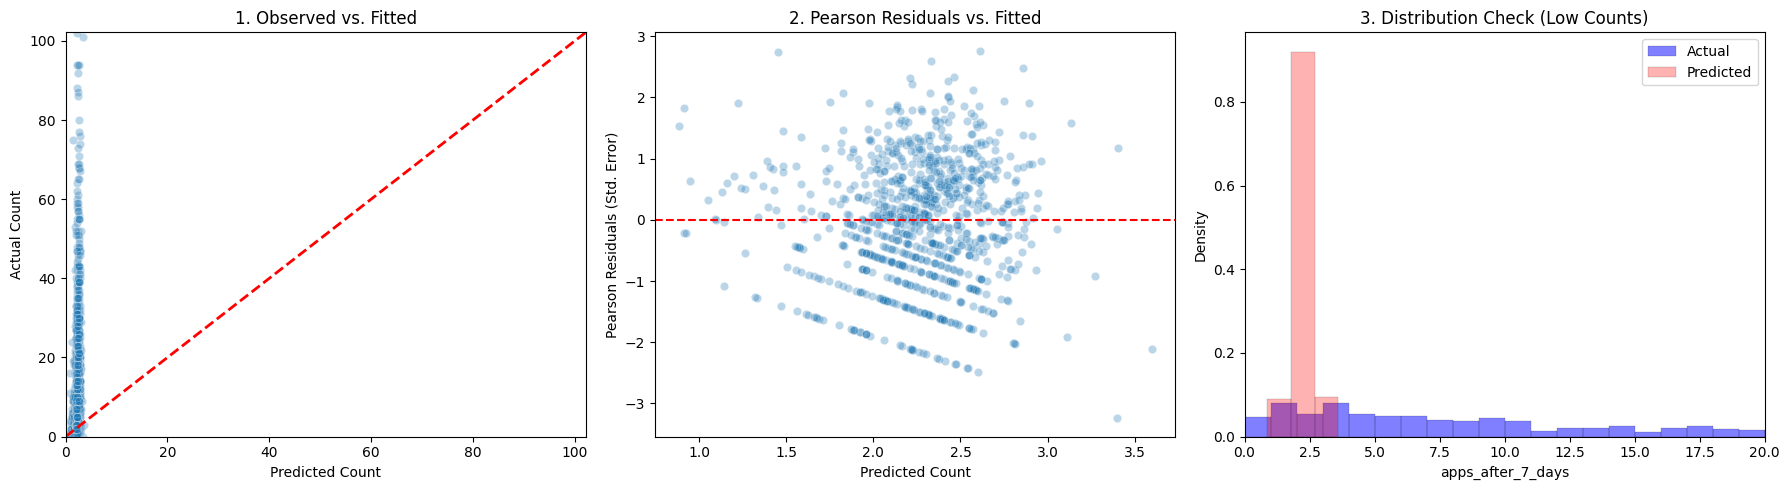

--- DIAGNOSTIC METRICS ---


AttributeError: 'OLSResults' object has no attribute 'prsquared'

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy import stats


def run_model_diagnostics(result_obj, df, target_col='apps_after_7_days'):
    """
    Runs industry-standard diagnostics for Negative Binomial / Count models.
    """
    # 1. Get Fitted Values and Actuals directly from the model result
    # This avoids the shape mismatch error
    fitted = result_obj.fittedvalues

    # We must ensure we align with the rows the model actually used
    # (in case some were dropped due to NaNs)
    # statsmodels stores the indices of the rows it used
    if hasattr(result_obj, 'model') and hasattr(result_obj.model, '_data_indices'):
        # For newer statsmodels with formula API
        actuals = df.loc[result_obj.model._data_indices, target_col]
    elif hasattr(result_obj.model, 'data') and hasattr(result_obj.model.data, 'row_labels'):
        # Fallback for other versions
        actuals = df.loc[result_obj.model.data.row_labels, target_col]
    else:
        # Fallback: assume df matches exactly if no Nans
        actuals = df[target_col]

    # Calculate Pearson Residuals (standardized for count models)
    # (Observed - Fitted) / sqrt(Variance)
    residuals = result_obj.resid_pearson

    # --- PLOT 1: Observed vs. Fitted (The "Reality Check") ---
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # We clip the plot to the 99th percentile to hide extreme viral outliers
    limit = np.percentile(actuals, 99)

    sns.scatterplot(x=fitted, y=actuals, alpha=0.3, ax=axes[0])
    axes[0].plot([0, limit], [0, limit], 'r--', lw=2)  # Perfect fit line
    axes[0].set_title("1. Observed vs. Fitted")
    axes[0].set_xlabel("Predicted Count")
    axes[0].set_ylabel("Actual Count")
    axes[0].set_xlim(0, limit)
    axes[0].set_ylim(0, limit)

    # --- PLOT 2: Residuals vs. Fitted (The "Bias Check") ---
    sns.scatterplot(x=fitted, y=residuals, alpha=0.3, ax=axes[1])
    axes[1].axhline(0, color='r', linestyle='--')
    axes[1].set_title("2. Pearson Residuals vs. Fitted")
    axes[1].set_xlabel("Predicted Count")
    axes[1].set_ylabel("Pearson Residuals (Std. Error)")
    # Look for 'fanning' or curves here

    # --- PLOT 3: The "Zero-Inflation" Check (Histogram) ---
    # Compare the actual distribution of counts vs. the predicted mean
    sns.histplot(actuals, stat='density', binwidth=1,
                 color='blue', alpha=0.5, label='Actual', ax=axes[2])
    sns.histplot(fitted, stat='density', binwidth=1, color='red',
                 alpha=0.3, label='Predicted', ax=axes[2])
    axes[2].set_xlim(0, 20)  # Focus on the low counts (0-20 apps)
    axes[2].set_title("3. Distribution Check (Low Counts)")
    axes[2].legend()

    plt.tight_layout()
    plt.show()

    # --- STATS SUMMARY ---
    print("--- DIAGNOSTIC METRICS ---")

    # 1. Pseudo R-squared (McFadden's)
    print(f"Pseudo R-squ. (McFadden): {result_obj.prsquared:.4f}")

    # 2. Alpha (Dispersion Parameter)
    # In statsmodels NegativeBinomial, 'alpha' is often stored directly or implied.
    # If using sm.GLM with NegBin family, it might be fixed.
    # If using sm.NegativeBinomial, it's a parameter.
    try:
        alpha_est = result_obj.params['alpha'] if 'alpha' in result_obj.params else "Fixed/Unknown"
        print(f"Alpha (Overdispersion):   {alpha_est}")
    except:
        pass

    # 3. Root Mean Squared Error (RMSE)
    rmse = np.sqrt(((fitted - actuals) ** 2).mean())
    print(f"RMSE (Error in count):    {rmse:.2f}")

    # 4. Zero Prediction Accuracy
    # How many zeros did we observe vs how many did the model expect?
    actual_zeros = (actuals == 0).mean()
    # For NegBin, P(y=0) depends on mu and alpha. A simple proxy is checking low fitted values.
    # But visually, Plot 3 is better.
    print(f"Actual % of Zeros:        {actual_zeros:.1%}")


# Usage:
run_model_diagnostics(runner.results['baseline'], final_og_model_df)

In [27]:
plot_observed_vs_fitted(runner.results['baseline'], final_og_model_df)

ValueError: shapes (933,78) and (18,) not aligned: 78 (dim 1) != 18 (dim 0)

In [16]:
# 1. Wrap the results
registry = ExperimentRegistry(runner.results, prompt_map)

# 2. Launch the viewer
interactive_model_viewer(registry)

Dropdown(description='Select Model:', layout=Layout(width='600px'), options=(('Qwen/Qwen3-4B-Instruct-2507 | B…

Output()

In [15]:
registry.run_all_pairwise_contrasts()

NameError: name 'registry' is not defined

### Models with log offset of time effects on average applications per deal

In [59]:
# Define options
offset_opts = [None, 'log_offset'][1]
cluster_opts = [None, 'partner_id'][0]

runner = create_regression_runner(
    TARGET, GROUPS, cluster_col=offset_opts, offset_col=cluster_opts)

# Run and store
res = runner.run_negative_binomial(
    df=final_model_df, cat_vars=CATS, bin_vars=BINS, num_vars=[], predictor_name='mean_rating'
)

interactive_regression_results_selector(res)

Dropdown(description='Select option:', layout=Layout(width='400px'), options=("('Qwen/Qwen3-4B-Instruct-2507',…

<class 'statsmodels.iolib.summary.Summary'>
"""
                           NegativeBinomial Regression Results                           
=========================================================================================
Dep. Variable:     applicants_applications_count   No. Observations:                 1462
Model:                          NegativeBinomial   Df Residuals:                     1446
Method:                                      MLE   Df Model:                           15
Date:                           Fri, 06 Feb 2026   Pseudo R-squ.:                0.006417
Time:                                   00:33:51   Log-Likelihood:                -5656.5
converged:                                  True   LL-Null:                       -5693.0
Covariance Type:                         cluster   LLR p-value:                 1.264e-09
==================================================================================================
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                              2.7623      0.078     35.315      0.000       2.605       2.920
Call-to-action strength            0.0582      0.063      0.928      0.358      -0.068       0.184
Clarity                            0.0422      0.048      0.882      0.383      -0.054       0.139
Persuasiveness                    -0.0482      0.061     -0.791      0.433      -0.171       0.075
first_content_type_Beauty          0.2877      0.066      4.377      0.000       0.155       0.420
first_content_type_Experiences     0.2461      0.062      3.939      0.000       0.120       0.372
first_content_type_Fashion         0.2877      0.080      3.604      0.001       0.127       0.448
first_content_type_Food            0.2860      0.075      3.806      0.000       0.135       0.437
first_content_type_Luxury          0.1620      0.089      1.825      0.075      -0.017       0.341
first_content_type_UGC             0.2581      0.058      4.418      0.000       0.140       0.376
deal_language_nl                   0.0238      0.039      0.615      0.542      -0.054       0.102
social_requirement_type_id_2      -0.1317      0.058     -2.254      0.029      -0.249      -0.014
social_requirement_type_id_3      -0.1628      0.069     -2.369      0.022      -0.301      -0.024
social_requirement_type_id_4      -0.2472      0.095     -2.611      0.012      -0.438      -0.056
social_requirement_type_id_5      -0.6865      0.113     -6.087      0.000      -0.914      -0.459
social_requirement_type_id_6      -0.5469      0.250     -2.190      0.034      -1.050      -0.044
alpha                              0.5707      0.032     17.830      0.000       0.506       0.635
==================================================================================================
"""

- Time effect as offset

In [ ]:
# Create runner with offset
runner = create_regression_runner(
    target_col=TARGET,
    experimental_groups=GROUPS,
    offset_col='log_offset'  # Pre-computed log(monthly mean)
)

# Run regression
results = runner.run_negative_binomial(
    df=final_model_df,
    cat_vars=CATS,
    bin_vars=BINS,
    num_vars=[],  # No additional numerical predictors
    predictor_name='mean_rating'
)

interactive_regression_results_selector(results)

Dropdown(description='Select option:', index=1, layout=Layout(width='400px'), options=("('Qwen/Qwen3-4B-Instru…

<class 'statsmodels.iolib.summary.Summary'>
"""
                     NegativeBinomial Regression Results                      
==============================================================================
Dep. Variable:      apps_after_7_days   No. Observations:                 2159
Model:               NegativeBinomial   Df Residuals:                     2146
Method:                           MLE   Df Model:                           12
Date:                Fri, 06 Feb 2026   Pseudo R-squ.:                 0.01134
Time:                        00:10:14   Log-Likelihood:                -8005.3
converged:                       True   LL-Null:                       -8097.1
Covariance Type:            nonrobust   LLR p-value:                 7.803e-33
==================================================================================================
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                             -0.1547      0.104     -1.485      0.137      -0.359       0.049
mean_rating                        0.0116      0.026      0.453      0.651      -0.039       0.062
first_content_type_Beauty          0.4071      0.081      5.004      0.000       0.248       0.567
first_content_type_Experiences     0.1066      0.074      1.450      0.147      -0.037       0.251
first_content_type_Fashion         0.5216      0.084      6.192      0.000       0.356       0.687
first_content_type_Food            0.2570      0.074      3.471      0.001       0.112       0.402
first_content_type_Luxury          0.5827      0.077      7.548      0.000       0.431       0.734
first_content_type_UGC             0.3981      0.067      5.986      0.000       0.268       0.528
social_requirement_type_id_2       0.0160      0.072      0.223      0.823      -0.125       0.157
social_requirement_type_id_3      -0.2362      0.070     -3.365      0.001      -0.374      -0.099
social_requirement_type_id_4      -0.4116      0.085     -4.854      0.000      -0.578      -0.245
social_requirement_type_id_5      -1.0027      0.130     -7.738      0.000      -1.257      -0.749
social_requirement_type_id_6      -0.0537      0.196     -0.274      0.784      -0.438       0.330
alpha                              0.9030      0.027     32.973      0.000       0.849       0.957
==================================================================================================
"""

- Clustered errors

In [ ]:

# Create runner with offset
runner = create_regression_runner(
    target_col=TARGET,
    experimental_groups=GROUPS,
    cluster_col='partner_id',
    offset_col='log_offset'  # Pre-computed log(monthly mean)
)

# Run regression
results = runner.run_negative_binomial(
    df=final_model_df,
    cat_vars=CATS,
    bin_vars=BINS,
    num_vars=[],  # No additional numerical predictors
    predictor_name='mean_rating'
)

interactive_regression_results_selector(results)

Dropdown(description='Select option:', layout=Layout(width='400px'), options=("('Qwen/Qwen3-4B-Instruct-2507',…

<class 'statsmodels.iolib.summary.Summary'>
"""
                           NegativeBinomial Regression Results                           
=========================================================================================
Dep. Variable:     applicants_applications_count   No. Observations:                 1548
Model:                          NegativeBinomial   Df Residuals:                     1533
Method:                                      MLE   Df Model:                           14
Date:                           Fri, 06 Feb 2026   Pseudo R-squ.:                0.005707
Time:                                   00:18:35   Log-Likelihood:                -5955.8
converged:                                  True   LL-Null:                       -5990.0
Covariance Type:                         cluster   LLR p-value:                 3.806e-09
==================================================================================================
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                             -0.1263      0.101     -1.248      0.213      -0.325       0.072
Call-to-action strength            0.0981      0.042      2.309      0.021       0.015       0.181
Clarity                            0.0318      0.046      0.689      0.491      -0.059       0.122
Persuasiveness                    -0.0753      0.057     -1.314      0.189      -0.188       0.037
first_content_type_Beauty          0.2593      0.090      2.887      0.004       0.083       0.436
first_content_type_Experiences     0.2278      0.073      3.137      0.002       0.085       0.370
first_content_type_Fashion         0.2348      0.083      2.824      0.005       0.072       0.398
first_content_type_Food            0.2502      0.089      2.796      0.005       0.075       0.426
first_content_type_Luxury          0.1553      0.085      1.831      0.067      -0.011       0.322
first_content_type_UGC             0.2408      0.076      3.186      0.001       0.092       0.389
social_requirement_type_id_2      -0.1070      0.076     -1.406      0.160      -0.256       0.042
social_requirement_type_id_3      -0.1623      0.069     -2.364      0.018      -0.297      -0.028
social_requirement_type_id_4      -0.2018      0.092     -2.184      0.029      -0.383      -0.020
social_requirement_type_id_5      -0.6827      0.114     -5.984      0.000      -0.907      -0.459
social_requirement_type_id_6      -0.4756      0.213     -2.237      0.026      -0.893      -0.058
alpha                              0.5948      0.024     24.755      0.000       0.548       0.642
==================================================================================================
"""

- Time effect as predictor

In [29]:
# Create runner with offset
runner = create_regression_runner(
    target_col=TARGET,
    experimental_groups=GROUPS,
)

# Run regression
results = runner.run_negative_binomial(
    df=final_model_df,
    cat_vars=CATS,
    bin_vars=BINS,
    num_vars=['log_offset'],  # No additional numerical predictors
    predictor_name='mean_rating'
)

interactive_regression_results_selector(results)

Dropdown(description='Select option:', index=3, layout=Layout(width='400px'), options=("('Qwen/Qwen3-4B-Instru…

<class 'statsmodels.iolib.summary.Summary'>
"""
                     NegativeBinomial Regression Results                      
==============================================================================
Dep. Variable:      apps_after_7_days   No. Observations:                 3162
Model:               NegativeBinomial   Df Residuals:                     3148
Method:                           MLE   Df Model:                           13
Date:                Fri, 06 Feb 2026   Pseudo R-squ.:                 0.01639
Time:                        00:12:25   Log-Likelihood:                -12017.
converged:                       True   LL-Null:                       -12218.
Covariance Type:            nonrobust   LLR p-value:                 1.772e-77
==================================================================================================
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                              0.0823      0.216      0.381      0.703      -0.341       0.506
mean_rating                        0.0615      0.016      3.834      0.000       0.030       0.093
log_offset                         0.8381      0.073     11.496      0.000       0.695       0.981
first_content_type_Beauty          0.2934      0.069      4.241      0.000       0.158       0.429
first_content_type_Experiences     0.0124      0.062      0.200      0.842      -0.109       0.134
first_content_type_Fashion         0.4181      0.071      5.871      0.000       0.279       0.558
first_content_type_Food            0.1318      0.067      1.973      0.049       0.001       0.263
first_content_type_Luxury          0.5029      0.062      8.095      0.000       0.381       0.625
first_content_type_UGC             0.2728      0.056      4.903      0.000       0.164       0.382
social_requirement_type_id_2       0.1742      0.052      3.347      0.001       0.072       0.276
social_requirement_type_id_3      -0.1032      0.052     -1.983      0.047      -0.205      -0.001
social_requirement_type_id_4      -0.2513      0.067     -3.735      0.000      -0.383      -0.119
social_requirement_type_id_5      -0.8030      0.108     -7.433      0.000      -1.015      -0.591
social_requirement_type_id_6      -0.0591      0.175     -0.338      0.735      -0.402       0.283
alpha                              0.9686      0.024     40.695      0.000       0.922       1.015
==================================================================================================
"""

### Models without log offset of time effects on average applications per deal

#### Regular errors

In [ ]:
# Standard errors
runner = create_regression_runner(TARGET, GROUPS)
results = runner.run_negative_binomial(df=final_model_df,
                                       cat_vars=CATS,
                                       bin_vars=BINS,
                                       num_vars=[],
                                       predictor_name=SCORE_VAR,
                                       dims_to_exclude=None)

interactive_regression_results_selector(results)

Dropdown(description='Select option:', layout=Layout(width='400px'), options=("('Qwen/Qwen3-4B-Instruct-2507',…

<class 'statsmodels.iolib.summary.Summary'>
"""
                     NegativeBinomial Regression Results                      
==============================================================================
Dep. Variable:      apps_after_7_days   No. Observations:                 2169
Model:               NegativeBinomial   Df Residuals:                     2154
Method:                           MLE   Df Model:                           14
Date:                Fri, 06 Feb 2026   Pseudo R-squ.:                 0.01232
Time:                        00:13:52   Log-Likelihood:                -8064.5
converged:                       True   LL-Null:                       -8165.1
Covariance Type:            nonrobust   LLR p-value:                 3.116e-35
==================================================================================================
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                              2.4740      0.101     24.518      0.000       2.276       2.672
Call-to-action strength            0.0963      0.044      2.169      0.030       0.009       0.183
Clarity                            0.0470      0.046      1.016      0.310      -0.044       0.138
Persuasiveness                    -0.1110      0.057     -1.935      0.053      -0.223       0.001
first_content_type_Beauty          0.4316      0.082      5.259      0.000       0.271       0.592
first_content_type_Experiences     0.1217      0.074      1.645      0.100      -0.023       0.267
first_content_type_Fashion         0.5216      0.085      6.149      0.000       0.355       0.688
first_content_type_Food            0.2387      0.075      3.202      0.001       0.093       0.385
first_content_type_Luxury          0.6065      0.078      7.790      0.000       0.454       0.759
first_content_type_UGC             0.4430      0.067      6.605      0.000       0.312       0.574
social_requirement_type_id_2       0.0705      0.073      0.968      0.333      -0.072       0.213
social_requirement_type_id_3      -0.1828      0.071     -2.583      0.010      -0.322      -0.044
social_requirement_type_id_4      -0.4066      0.085     -4.760      0.000      -0.574      -0.239
social_requirement_type_id_5      -0.8944      0.131     -6.827      0.000      -1.151      -0.638
social_requirement_type_id_6       0.0537      0.198      0.272      0.786      -0.334       0.442
alpha                              0.9235      0.028     33.215      0.000       0.869       0.978
==================================================================================================
"""

#### Clustered errors

In [ ]:
# Clustered errors
runner = create_regression_runner(TARGET, GROUPS, cluster_col='partner_id')
results = runner.run_negative_binomial(df=final_model_df,
                                       cat_vars=CATS,
                                       bin_vars=BINS,
                                       num_vars=[],
                                       predictor_name=SCORE_VAR,
                                       dims_to_exclude=None)

interactive_regression_results_selector(results)

Dropdown(description='Select option:', index=2, layout=Layout(width='400px'), options=("('Qwen/Qwen3-4B-Instru…

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:      apps_after_7_days   No. Observations:                  661
Model:                            GLM   Df Residuals:                      659
Model Family:        NegativeBinomial   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2325.9
Date:                Wed, 04 Feb 2026   Deviance:                       1105.4
Time:                        12:46:36   Pearson chi2:                 1.14e+03
No. Iterations:                     6   Pseudo R-squ. (CS):            0.01030
Covariance Type:              cluster                                         
===============================================================================
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           2.9146      0.257     11.323      0.000       2.410       3.419
mean_rating    -0.1229      0.070     -1.765      0.078      -0.259       0.014
===============================================================================
"""

-------------

# EDA

## DF with LLM ratings

In [20]:
final_df

,applicants_applications_count,content_types,deal_id,main_image,min_social_media_followers,deal_tags,live_since,created_at,updated_at,deleted_at,...,top_k_tokens,constrained_tokens,sorted_tokens,sorted_logits,mean_rating,mode_rating,scale_size,entropy,normalized_entropy,first_content_type
0,39,"[{'id': 41, 'name': 'Activities', 'slug': 'per...",0196edc7-e6a8-00c8-6ff5-ea60fa3f2895,uploads/deals/0196edc7-5969-ffff-6700-7ae699b8...,2500,None,2025-05-20 15:21:28.249567,2025-05-20 13:00:23.080212,2025-10-28 10:55:34.719187,NaT,...,"[[4, 3, âģ, 5, ï¸ı, 2, âĳ, 1, 6, âĤ, 8, 7, **,...","[1, 2, 3, 4]","[1, 2, 3, 4]","[[22.272668838500977, 24.347896575927734, 32.4...",3.993179,4.0,4,0.040829,0.029452,Activities
1,39,"[{'id': 41, 'name': 'Activities', 'slug': 'per...",0196edc7-e6a8-00c8-6ff5-ea60fa3f2895,uploads/deals/0196edc7-5969-ffff-6700-7ae699b8...,2500,None,2025-05-20 15:21:28.249567,2025-05-20 13:00:23.080212,2025-10-28 10:55:34.719187,NaT,...,"[[3, 4, 2, ï¸ı, âģ, 5, **, 8, âĳ, 1, 7, Â³, 6,...","[1, 2, 3, 4]","[1, 2, 3, 4]","[[20.866113662719727, 25.588775634765625, 34.1...",3.147041,3.0,4,0.419342,0.302492,Activities
2,39,"[{'id': 41, 'name': 'Activities', 'slug': 'per...",0196edc7-e6a8-00c8-6ff5-ea60fa3f2895,uploads/deals/0196edc7-5969-ffff-6700-7ae699b8...,2500,None,2025-05-20 15:21:28.249567,2025-05-20 13:00:23.080212,2025-10-28 10:55:34.719187,NaT,...,"[[4, 3, ï¸ı, âģ, 5, 2, **, âŃĲ, 8, 7, âĳ, Ġ**,...","[1, 2, 3, 4]","[1, 2, 3, 4]","[[19.44389533996582, 22.37546157836914, 31.478...",3.866884,4.0,4,0.392396,0.283054,Activities
3,39,"[{'id': 41, 'name': 'Activities', 'slug': 'per...",0196edc7-e6a8-00c8-6ff5-ea60fa3f2895,uploads/deals/0196edc7-5969-ffff-6700-7ae699b8...,2500,None,2025-05-20 15:21:28.249567,2025-05-20 13:00:23.080212,2025-10-28 10:55:34.719187,NaT,...,"[[3, 4, 2, ï¸ı, 5, âģ, Â³, 1, **, 8, 6, 7, âĤ,...","[1, 2, 3, 4]","[1, 2, 3, 4]","[[21.82582664489746, 25.752683639526367, 36.06...",3.191083,3.0,4,0.488141,0.352119,Activities
4,39,"[{'id': 41, 'name': 'Activities', 'slug': 'per...",0196edc7-e6a8-00c8-6ff5-ea60fa3f2895,uploads/deals/0196edc7-5969-ffff-6700-7ae699b8...,2500,None,2025-05-20 15:21:28.249567,2025-05-20 13:00:23.080212,2025-10-28 10:55:34.719187,NaT,...,"[[5, 4, **, âģ, ï¸ı, 3, â, Ġ**, 6, âĳ, âĺħâĺħ,...","[1, 2, 3, 4, 5]","[1, 2, 3, 4, 5]","[[16.677732467651367, 15.764606475830078, 21.4...",4.975333,5.0,5,0.115684,0.071878,Activities
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19573,0,"[{'id': 41, 'name': 'Activities', 'slug': 'per...",01983c98-87ee-00c8-e551-8fd9afde13aa,,5000,None,NaT,2025-07-24 13:21:25.998303,2025-10-28 10:51:32.951354,NaT,...,"[[2, 1, 3, 4, 0, âĤĤ, Â², 5, Û, âĳ, ðĿ, Ù, ï¸ı...","[1, 2, 3, 4]","[1, 2, 3, 4]","[[37.06218338012695, 40.88780212402344, 36.903...",1.996931,2.0,4,0.191077,0.137833,Activities
19574,11,"[{'id': 23, 'name': 'Food', 'slug': 'Pizza'}, ...",01985b50-e6ec-00c8-6e60-feda42ee959b,uploads/deals/01985b50-e749-ffff-7870-e6157feb...,10000,None,2025-07-30 12:32:26.149352,2025-07-30 12:31:25.420062,2025-10-28 10:50:04.770145,NaT,...,"[[4, 3, 5, 2, âģ, 1, 6, âĳ, ï¸ı, 8, Û, 7, 9, â...","[1, 2, 3, 4]","[1, 2, 3, 4]","[[24.78870391845703, 27.261417388916016, 35.28...",3.999295,4.0,4,0.005822,0.004200,Food
19575,11,"[{'id': 23, 'name': 'Food', 'slug': 'Pizza'}, ...",01985b50-e6ec-00c8-6e60-feda42ee959b,uploads/deals/01985b50-e749-ffff-7870-e6157feb...,10000,None,2025-07-30 12:32:26.149352,2025-07-30 12:31:25.420062,2025-10-28 10:50:04.770145,NaT,...,"[[4, 3, 2, 5, âģ, 6, 1, 8, 7, âĳ, Â³, 9, ï¸ı, ...","[1, 2, 3, 4]","[1, 2, 3, 4]","[[24.783130645751953, 29.421804428100586, 39.7...",3.824085,4.0,4,0.465200,0.335571,Food
19576,11,"[{'id': 23, 'name': 'Food', 'slug': 'Pizza'}, ...",01985b50-e6ec-00c8-6e60-feda42ee959b,uploads/deals/01985b50-e749-ffff-7870-e6157feb...,10000,None,2025-07-30 12:32:26.149352,2025-07-30 12:31:25.420062,2025-10-28 10:50:04.770145,NaT,...,"[[2, 3, 1, 4, 5, 0, Ġ**, âĤĤ, 6, Â², **, Â½, Û...","[1, 2, 3, 4]","[1,

## Raw data

In [22]:
og_df

,applicants_applications_count,content_types,deal_id,main_image,min_social_media_followers,deal_tags,live_since,created_at,updated_at,deleted_at,...,legacy_id,tags,gender,featured_image,company_id,test_nr_of_apps,update_at_date,diff,apps_after_7_days,apps_after_7_days_OLD
0,39,"[{'id': 41, 'name': 'Activities', 'slug': 'per...",0196edc7-e6a8-00c8-6ff5-ea60fa3f2895,uploads/deals/0196edc7-5969-ffff-6700-7ae699b8...,2500,None,2025-05-20 15:21:28.249567,2025-05-20 13:00:23.080212,2025-10-28 10:55:34.719187,NaT,...,NaN,None,None,None,0199f1d4-b501-015e-5c45-1bc8300b3949,39,2025-10-28,0,39,39.0
1,0,"[{'id': 21, 'name': 'Fashion', 'slug': 'Dress'}]",019689e5-f489-00c8-8c26-06b3ea0961a5,uploads/deals/019689e5-f54b-ffff-dbed-637e9d2a...,5000,None,2023-11-28 14:59:51.626780,2023-11-28 14:59:51.626780,2025-05-01 03:31:11.600095,NaT,...,487.0,None,None,None,None,0,2025-05-01,0,0,0.0
2,23,"[{'id': 29, 'name': 'UGC', 'slug': 'Film-Strip'}]",019689e2-bfb5-00c8-6485-23352d64b0e5,uploads/deals/019689e2-c06c-ffff-baf0-c7e9decd...,5000,None,2025-03-04 11:46:18.176627,2025-03-04 11:46:18.176627,2025-05-01 03:27:41.316646,NaT,...,3593.0,None,None,None,None,23,2025-05-01,0,13,13.0
3,43,"[{'id': 21, 'name': 'Fashion', 'slug': 'Dress'}]",019689e3-d7a5-00c8-f5a8-6bfe51a21cd6,uploads/deals/019689e3-d86f-ffff-a03e-d38765a0...,2500,None,2025-04-17 09:50:45.518632,2025-04-17 09:50:45.518632,2025-06-08 09:05:21.413273,NaT,...,4228.0,None,None,None,None,43,2025-06-08,0,19,19.0
4,13,"[{'id': 19, 'name': 'Sport', 'slug': 'Soccer-B...",019689e5-7dd0-00c8-615b-7750a8fec2f3,uploads/deals/019689e5-7f9d-ffff-5b6d-a335c1ce...,2500,None,2025-02-10 18:19:51.240203,2025-02-10 18:19:51.240203,2025-10-28 10:51:05.147656,NaT,...,3242.0,None,None,None,0199f1b0-2b6c-015e-e5b3-6b1dd7564d3a,13,2025-10-28,0,13,13.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5106,9,"[{'id': 39, 'name': 'Experiences', 'slug': 'Te...",019689e5-4642-00c8-08dd-41d776586f1c,uploads/deals/019689e5-46b6-ffff-2159-fb70a484...,50000,None,2024-03-26 14:09:02.539962,2024-03-26 14:09:02.539962,2025-10-28 10:54:41.617599,NaT,...,865.0,None,None,None,0199f1cc-e3f7-015e-432a-d2035c7ba015,9,2025-10-28,0,5,5.0
5107,11,"[{'id': 39, 'name': 'Experiences', 'slug': 'Te...",019689e5-6ce0-00c8-5fdd-a058811d2946,uploads/deals/019689e5-6e0d-ffff-4a2f-362bb635...,10000,None,2024-10-17 14:59:27.484092,2024-10-17 14:59:27.484092,2025-10-28 10:52:42.692581,NaT,...,1889.0,None,None,None,0199f1c3-fcaf-015e-eeb9-cc244704412b,11,2025-10-28,0,7,7.0
5108,0,"[{'id': 23, 'name': 'Food', 'slug': 'Pizza'}]",0198324e-635d-00c8-7d1d-bbb0b902b0d9,,10000,None,NaT,2025-07-22 13:24:14.813323,2025-10-28 11:04:12.121141,NaT,...,NaN,None,None,None,0199f18e-af17-015e-23aa-c780e5c4a2b8,0,2025-10-28,0,0,NaN
5109,0,"[{'id': 41, 'name': 'Activities', 'slug': 'per...",01983c98-87ee-00c8-e551-8fd9afde13aa,,5000,None,NaT,2025-07-24 13:21:25.998303,2025-10-28 10:51:32.951354,NaT,...,NaN,None,None,None,0199f1b6-5645-015e-ffbf-5e1786a1e5c3,0,2025-10-28,0,0,NaN


In [13]:
og_df.first_content_type.value_counts()

first_content_type
Activities       1300
UGC               832
Food              788
Experiences       718
Luxury            575
Beauty            498
Fashion           434
Cooking           211
Lifestyle         208
Drinks            146
Sport             130
Tech              115
Mom               102
Travel             94
Entertainment      73
Music              67
Animals            51
Cars               40
Photography        22
Finance            21
Vegan              16
Gaming             12
None               11
Nightlife           6
Movie               2
Name: count, dtype: int64

## General analyis of the cleaned model df 

In [14]:
final_og_model_df

,created_at,updated_at,deleted_at,id,legacy_partner_id,deal_title,deal_text,creators_requirement,hash_tags,status,...,total_company_locations,upcoming_applications_count,first_content_type,apps_after_7_days,deal_language,days_since_start,log_deal_value,month,log_apps,log_offset
21,2025-01-30 12:32:17.419293,2026-01-13 10:00:30.108921,NaT,019689e3-dcdc-00c8-ceac-61b3133e1ec8,969.0,Simracen en borrelen inc. borrelplank en drankjes,Ben jij influencer en wil je jouw volgers late...,Suggestions & requirements:\n\nContent moet mi...,#racesquare,inactive,...,7,42,Activities,58,nl,511,4.605170,2025-01,4.077537,0.972577
37,2025-11-19 15:31:28.153146,2026-01-29 14:18:07.862033,NaT,019a9cbd-fd19-00c8-18be-7355ed5e0344,85.0,♻️ Statiegeld NL | Voorschoten Bulkmachine €100,Help Statiegeld Nederland om Nederland schoner...,• Maak 1 Instagram Reel (TikTok optioneel)\n• ...,#StatiegeldNederland,draft,...,1,0,Activities,14,nl,804,4.615121,2025-11,2.708050,0.937605
44,2025-07-31 08:49:42.211582,2026-01-12 07:39:40.970409,NaT,01985fac-4543-00c8-bec7-39daedc6ec92,1695.0,Tapasbar Plan B - Vega(n) diner voor 2 personen!,Bij Plan B hebben wij een groot aanbod aan veg...,Wij verwachten een video die gepost wordt op T...,"#tapas,#tapasbreda,#vega,#vegan,#breda,#foodbr...",live,...,1,3,Experiences,8,nl,692,4.709530,2025-07,2.197225,0.879166
46,2025-07-31 09:01:47.423425,2026-01-12 07:39:41.014016,NaT,01985fb7-561f-00c8-9275-2a7e0744a116,1695.0,5L Sangria met 5 vrienden!,Bij Tapasbar Plan B serveren wij een heerlijke...,Een foto of video van de sangria op je eigen I...,"#sangria,#tapas,#breda,#tapasbreda,#sangriabre...",live,...,1,0,Food,9,nl,692,4.709530,2025-07,2.302585,0.879166
91,2025-09-09 13:54:30.557941,2026-01-12 07:39:17.699821,NaT,01992ec1-b41d-00c8-a494-e382d81ba7f4,840.0,Microdermabrasie facial (goud) 60 min,oppervlaktereiniging - dieptereiniging met ski...,Bruikbare content voor onze eigen kanalen verz...,"#Gorinchem,#CleyoGorinchem,#cleyoskinexperts,#...",finished,...,1,4,Beauty,10,nl,733,4.653960,2025-09,2.397895,0.867636
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7244,2025-09-22 13:41:49.968953,2026-01-31 23:03:50.592176,NaT,019971a8-c510-00c8-f19b-d8b34c3cf589,2530.0,Test de ultieme slaapoordop en deel je ervaring,Dit najaar lanceren we Silent Sleep: een nieuw...,In ruil voor op maat gemaakte gehoorbeschermin...,"#Pluggerz,#SilentSleep",finished,...,0,4,Beauty,18,nl,746,5.017280,2025-09,2.944439,0.867636
7254,2026-01-06 19:38:22.031803,2026-01-31 23:03:57.681625,NaT,019b94d1-47cf-00c8-9903-09fc53dfef3c,3008.0,4 Free Kids Books + Earn Cash Per Sale 📚,<p>Calling&nbsp;all&nbsp;family&nbsp;&amp;&nbs...,<p>What&nbsp;we&nbsp;need&nbsp;from&nbsp;you:&...,"#MomTok,#KidsBooks,#MomLife,#KidsReading,#Pare...",finished,...,0,5,Experiences,7,en,852,5.017280,2026-01,2.079442,0.883933
7255,2026-01-14 14:35:03.139577,2026-01-31 23:03:58.277275,NaT,019bbcee-7663-00c8-dc81-a59920160cfb,NaN,Boekevent Meer dan konijneneten,<p>Voor&nbsp;de&nbsp;lancering&nbsp;van&nbsp;m...,<p>🤍&nbsp;Wat&nbsp;ik&nbsp;vraag&nbsp;in&nbsp;...,"#darmgezondheid,#glutenvrij,#lowcarb,#meerdank...",finished,...,0,2,Activities,7,nl,860,4.615121,2026-01,2.079442,0.883933
7256,2025-11-19 11:06:14.956270,2026-01-22 12:49:17.099441,NaT,019a9bcb-2c2c-00c8-4446-49d1e6aed03e,3267.0,🎉 Paid UGC Collaboration with Barter (TikTok),<p>We’re&nbsp;looking&nbsp;for&nbsp;Content&nb...,<p>•&nbsp;We&nbsp;will&nbsp;provide&nbsp;a&nbs...,"#UGC,#ugccreator,#ugccontentcreator,#ugccommunity",live,...,0,0,Activities,9,en,804,5.017280,2025-11,2.302585,0.937605


In [17]:
final_og_model_df.groupby('social_requirement_type_id')['applicants_applications_count'].sum()


social_requirement_type_id
1.0    12980
2.0    11318
3.0     7224
4.0     2905
5.0      344
6.0      359
Name: applicants_applications_count, dtype: int64

In [40]:
final_og_model_df.groupby('min_social_media_followers')['apps_after_7_days'].sum()

min_social_media_followers
1500     4895
2500     4986
5000     2910
10000    1333
Name: apps_after_7_days, dtype: int64

In [20]:
final_og_model_df.groupby('social_requirement_type_id')['apps_after_7_days'].sum()

social_requirement_type_id
1.0    4895
2.0    4986
3.0    2910
4.0    1333
5.0     191
6.0     110
Name: apps_after_7_days, dtype: int64

In [15]:
final_og_model_df.social_requirement_type_id.value_counts()

social_requirement_type_id
1.0    290
2.0    238
3.0    212
4.0    109
5.0     37
6.0     14
Name: count, dtype: int64

## Analysis of the time component

In [17]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Ensure datetime format
og_df['created_at'] = pd.to_datetime(og_df['created_at'])

# 2. Extract a numeric 'Time' feature for correlation (e.g., Days since start)
# We subtract the minimum date to get a "Day 0", "Day 1"... counter
start_date = og_df['created_at'].min()
og_df['days_since_start'] = (og_df['created_at'] - start_date).dt.days


def visualise_var_over_time(y_variable='apps_after_7_days', agg_type='sum'):

    # 3. Visualization: Two Views

    fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=False)

    # View A: Raw Scatter (The Noise)
    # We sample 2000 points if the dataset is huge to prevent overplotting
    plot_data = og_df.sample(n=min(2000, len(og_df)), random_state=42)
    sns.scatterplot(
        data=plot_data,
        x='created_at',
        y='apps_after_7_days',
        alpha=0.3,
        ax=axes[0]
    )
    axes[0].set_title("Raw Data: Applications over Time")
    axes[0].set_ylabel("Apps after 7 Days")

    # View B: Monthly Trend (The Signal)
    # Resample by Month to see if the AVERAGE deal is getting more apps
    monthly_trend = og_df.set_index('created_at').resample('M')[
        y_variable].agg([agg_type, 'count'])
    sns.lineplot(data=monthly_trend, x=monthly_trend.index,
                 y=agg_type, ax=axes[1], color='red', linewidth=2)
    axes[1].set_title(
        f"Platform Trend: {agg_type} Applications per Deal (Monthly)")
    axes[1].set_ylabel(f"{agg_type} Apps per Deal")
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

    # 4. Statistical Check
    # Correlation between Time and Applications
    corr = og_df[['days_since_start', 'apps_after_7_days']].corr().iloc[0, 1]
    print(f"Correlation between Time and Application Count: {corr:.4f}")

    # Check for "Deal Volume" dilution
    # (Sometimes apps per deal DROP if deal volume grows faster than user base)
    volume_corr = monthly_trend[agg_type].corr(monthly_trend['count'])
    print(
        f"Correlation between Monthly Deal Volume and {agg_type} of {y_variable}: {volume_corr:.4f}")

- Average 'applications after 7 days' per deal over time

C:\Users\Wouter Barter\AppData\Local\Temp\ipykernel_1872\3926852071.py:35: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_trend = og_df.set_index('created_at').resample('M')[


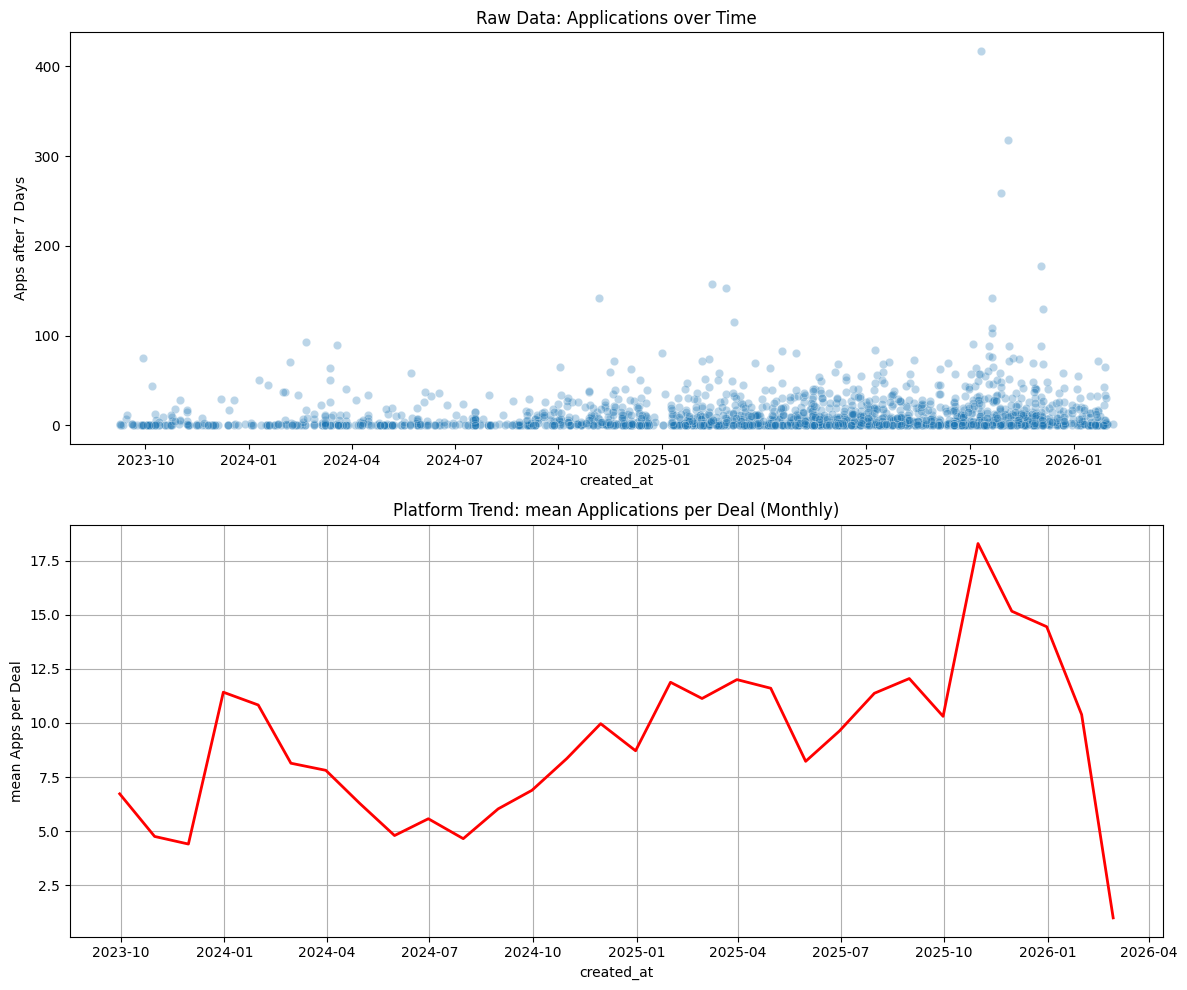

Correlation between Time and Application Count: 0.1095
Correlation between Monthly Deal Volume and mean of apps_after_7_days: 0.6988


In [18]:
visualise_var_over_time('apps_after_7_days', 'mean')

- Sum of 'applications after 7 days' per deal over time

C:\Users\Wouter Barter\AppData\Local\Temp\ipykernel_1872\3926852071.py:35: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_trend = og_df.set_index('created_at').resample('M')[


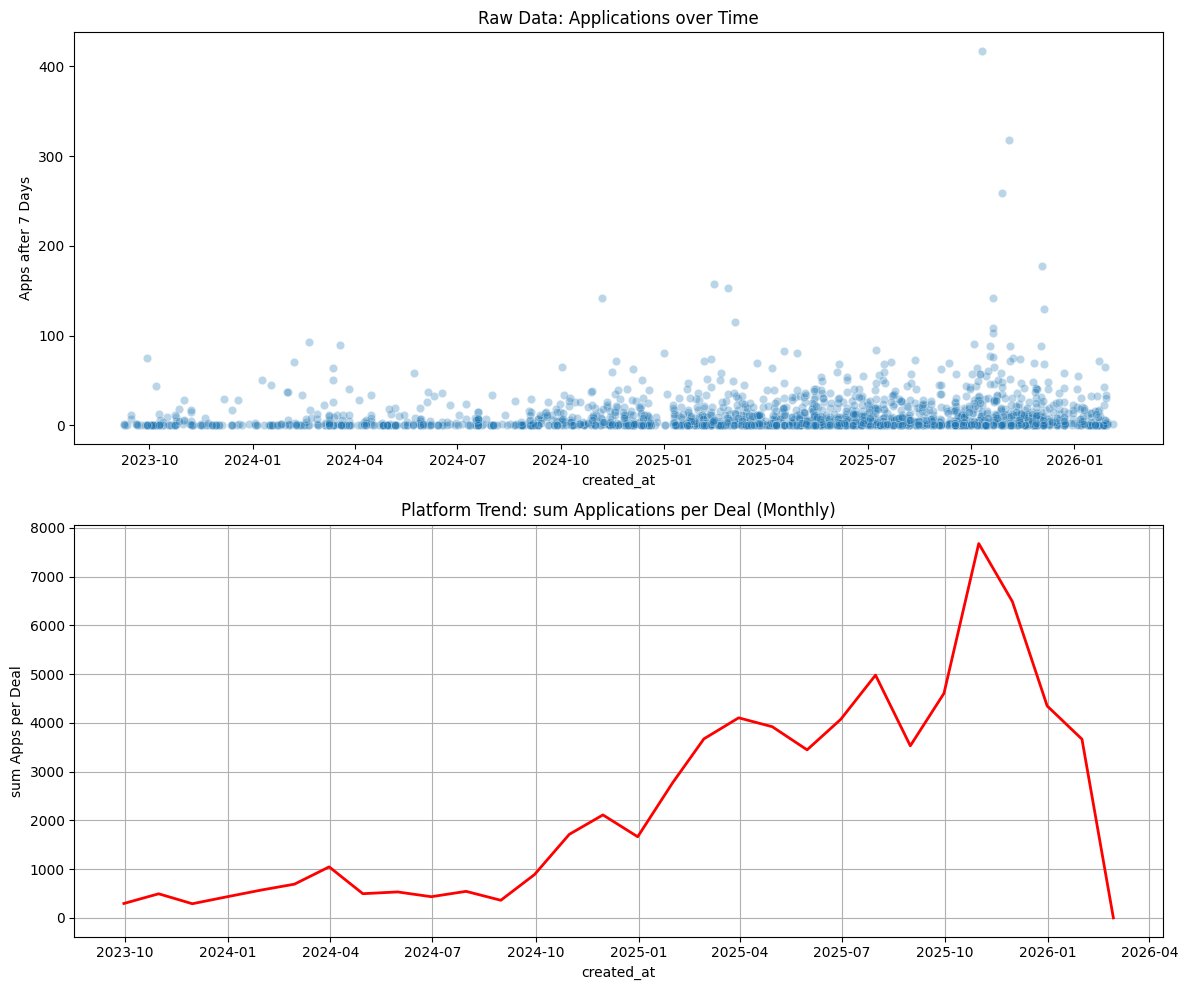

Correlation between Time and Application Count: 0.1095
Correlation between Monthly Deal Volume and sum of apps_after_7_days: 0.9348


In [19]:
visualise_var_over_time('apps_after_7_days', 'sum')

In [ ]:
def show_recent_weekly_stats(df, date_col='created_at', value_col='apps_after_7_days'):
    # 1. Setup Data
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col])

    # 2. Filter to last 52 weeks relative to the dataset's end
    last_date = df[date_col].max()
    start_date = last_date - pd.Timedelta(weeks=52)
    recent_df = df[df[date_col] >= start_date]

    # 3. Group by Week (W-MON starts weeks on Monday)
    weekly_stats = recent_df.set_index(date_col).resample('W-MON')[value_col].agg(
        Deals_Posted='count',
        Total_Apps='sum',
        Median_apps='median',
        Avg_Apps='mean',

    )

    # 4. Filter out empty weeks (optional)
    weekly_stats = weekly_stats[weekly_stats['Deals_Posted'] > 0]

    # 5. Display the last 10 weeks to pinpoint the drop
    # print("--- Weekly Performance (Last 12 Weeks) ---")
    # weekly_stats.tail(12)

    return weekly_stats


# Run it
weekly_table = show_recent_weekly_stats(og_df)
weekly_table

,Deals_Posted,Total_Apps,Median_apps,Avg_Apps
created_at,,,,
2025-02-10,53,584,4.0,11.018868
2025-02-17,94,1138,6.0,12.106383
2025-02-24,83,962,3.0,11.590361
2025-03-03,73,888,4.0,12.164384
2025-03-10,67,1100,8.0,16.417910
2025-03-17,94,1136,6.5,12.085106
2025-03-24,84,836,5.0,9.952381
2025-03-31,79,727,3.0,9.202532
2025-04-07,68,676,3.0,9.941176


📅 Data Max Date: 2026-02-04
✂️ Cutoff Date:   2025-12-06
🗑️ Dropping incomplete period ending: 2025-12-08


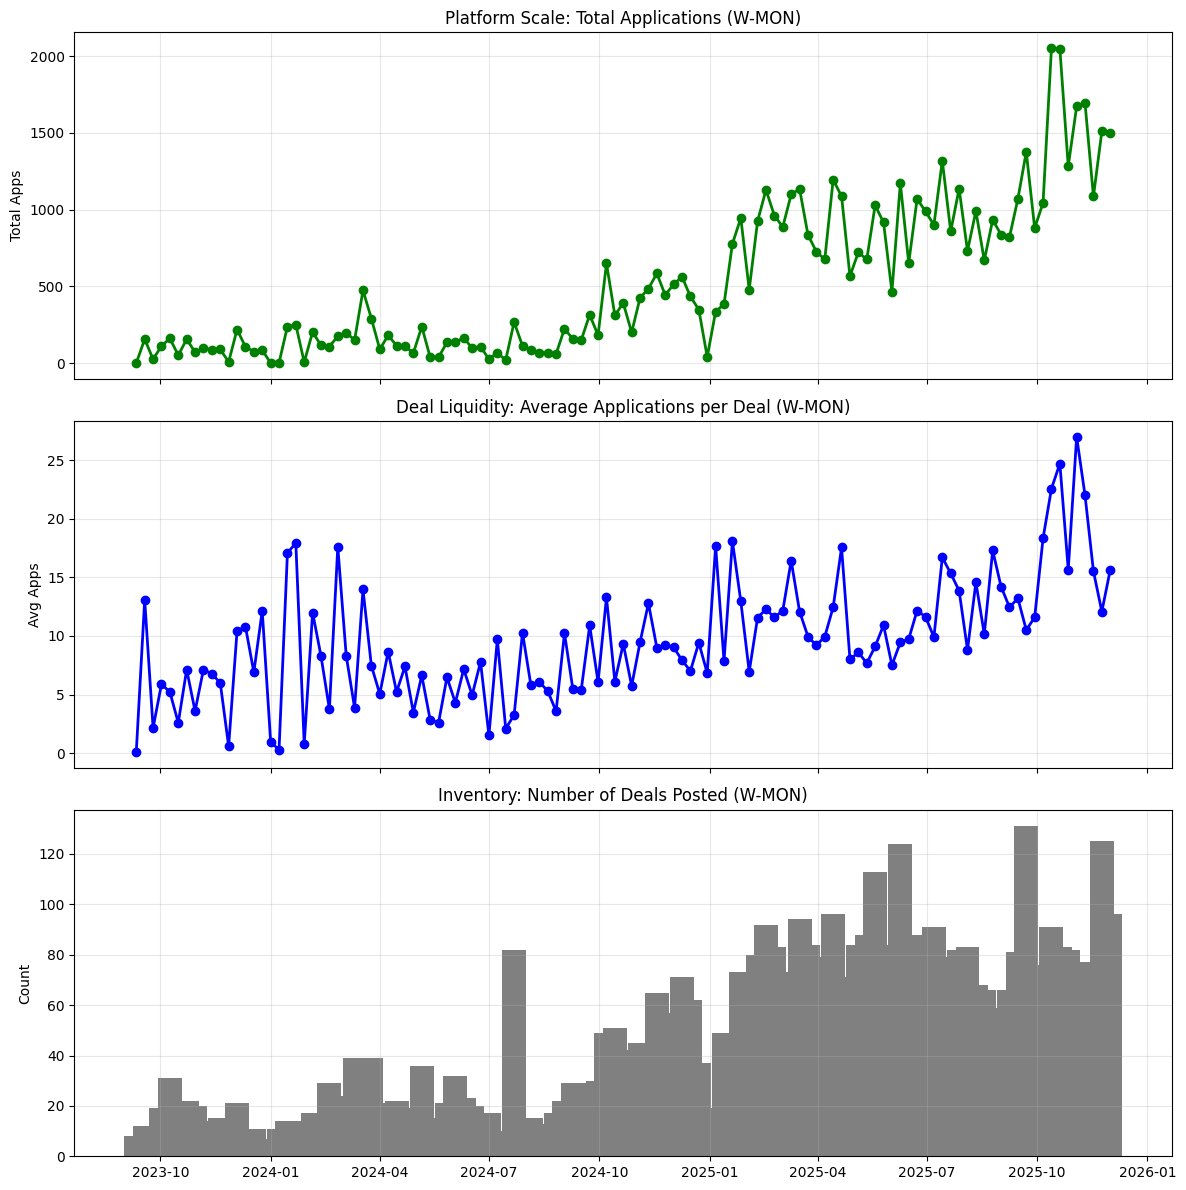

,Deals_Posted,Avg_Apps,Total_Apps
created_at,,,
2023-09-11,8,0.125000,1
2023-09-18,12,13.083333,157
2023-09-25,12,2.166667,26
2023-10-02,19,5.894737,112
2023-10-09,31,5.225806,162
...,...,...,...
2025-11-03,62,26.983871,1673
2025-11-10,77,21.987013,1693
2025-11-17,70,15.528571,1087


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


def simple_trend_analysis(df, freq='W-MON', remove_last_n_days=7):
    """
    freq options: 
      'W-MON' = Weekly (starting Mondays)
      'MS'    = Monthly (Start of Month)
    """
    # 1. Setup Data
    df = df.copy()
    df['created_at'] = pd.to_datetime(df['created_at'])

    # 2. Hard Cutoff
    max_date = df['created_at'].max()
    cutoff_date = max_date - pd.Timedelta(days=remove_last_n_days)

    print(f"📅 Data Max Date: {max_date.date()}")
    print(f"✂️ Cutoff Date:   {cutoff_date.date()}")

    clean_df = df[df['created_at'] < cutoff_date]

    # 3. Aggregate
    stats = clean_df.set_index('created_at').resample(freq)['apps_after_7_days'].agg(
        Deals_Posted='count',
        Avg_Apps='mean',
        Total_Apps='sum'
    )

    # 4. SAFETY STEP: Drop the very last bin
    print(f"🗑️ Dropping incomplete period ending: {stats.index[-1].date()}")
    stats = stats.iloc[:-1]

    # 5. Visualization (3 Subplots)
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

    # Plot A: Total Apps (Volume)
    ax1.plot(stats.index, stats['Total_Apps'],
             marker='o', color='green', linewidth=2)
    ax1.set_title(f"Platform Scale: Total Applications ({freq})")
    ax1.set_ylabel("Total Apps")
    ax1.grid(True, alpha=0.3)

    # Plot B: Average Apps (Liquidity)
    ax2.plot(stats.index, stats['Avg_Apps'],
             marker='o', color='blue', linewidth=2)
    ax2.set_title(f"Deal Liquidity: Average Applications per Deal ({freq})")
    ax2.set_ylabel("Avg Apps")
    ax2.grid(True, alpha=0.3)

    # Plot C: Deals Posted (Supply)
    bar_width = 20 if 'M' in freq else 4
    ax3.bar(stats.index, stats['Deals_Posted'], color='gray', width=bar_width)
    ax3.set_title(f"Inventory: Number of Deals Posted ({freq})")
    ax3.set_ylabel("Count")
    ax3.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return stats


# --- Usage ---
simple_analysis_df = og_df.copy()
simple_analysis_df = simple_analysis_df[simple_analysis_df['deal_language'] != 'de']
# simple_analysis_df = simple_analysis_df[simple_analysis_df['partner_id'] == 85]

simple_trend_analysis(simple_analysis_df, freq='W-MON', remove_last_n_days=60)

Correlation between Time and Quality: 0.0850


C:\Users\Wouter Barter\AppData\Local\Temp\ipykernel_1872\265439459.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_final_df['created_at'] = pd.to_datetime(subset_final_df['created_at'])
C:\Users\Wouter Barter\AppData\Local\Temp\ipykernel_1872\265439459.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_final_df['days_since_start'] = (


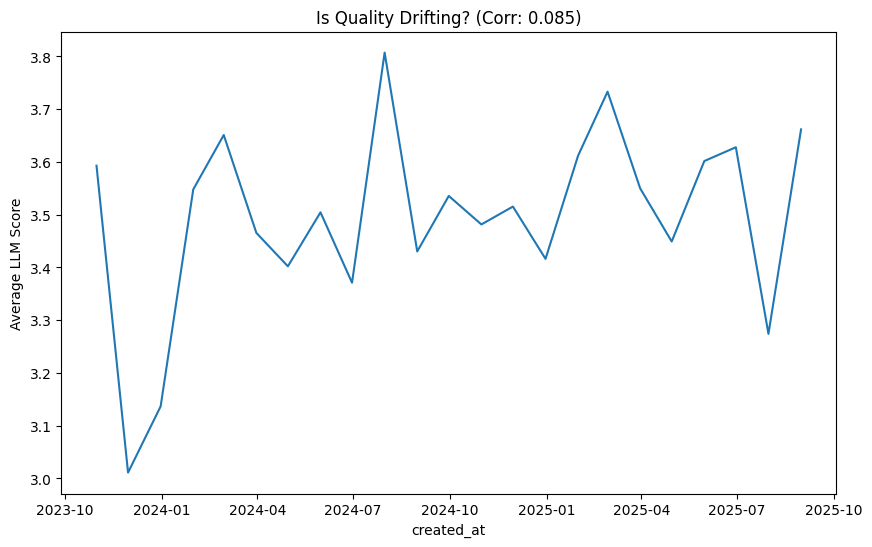

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
subset_final_df = final_df[final_df.prompt_id == 'd6ac463714']


# 1. Ensure datetime format
subset_final_df['created_at'] = pd.to_datetime(subset_final_df['created_at'])

# 2. Extract a numeric 'Time' feature for correlation (e.g., Days since start)
# We subtract the minimum date to get a "Day 0", "Day 1"... counter
start_date = subset_final_df['created_at'].min()
subset_final_df['days_since_start'] = (
    subset_final_df['created_at'] - start_date).dt.days

subset_final_df = subset_final_df[subset_final_df['days_since_start'] > 50]


# 1. Check if Quality correlates with Time
# We use the 'days_since_start' we created earlier
quality_time_corr = subset_final_df[[
    'days_since_start', 'mean_rating']].corr().iloc[0, 1]

print(f"Correlation between Time and Quality: {quality_time_corr:.4f}")

# 2. Visualize the drift

plt.figure(figsize=(10, 6))
# Plot monthly average quality to reduce noise
monthly_quality = subset_final_df.set_index('created_at').resample('ME')[
    'mean_rating'].mean()

sns.lineplot(x=monthly_quality.index, y=monthly_quality.values)
plt.title(f"Is Quality Drifting? (Corr: {quality_time_corr:.3f})")
plt.ylabel("Average LLM Score")
plt.show()

Correlation between Time and Quality: 0.0241


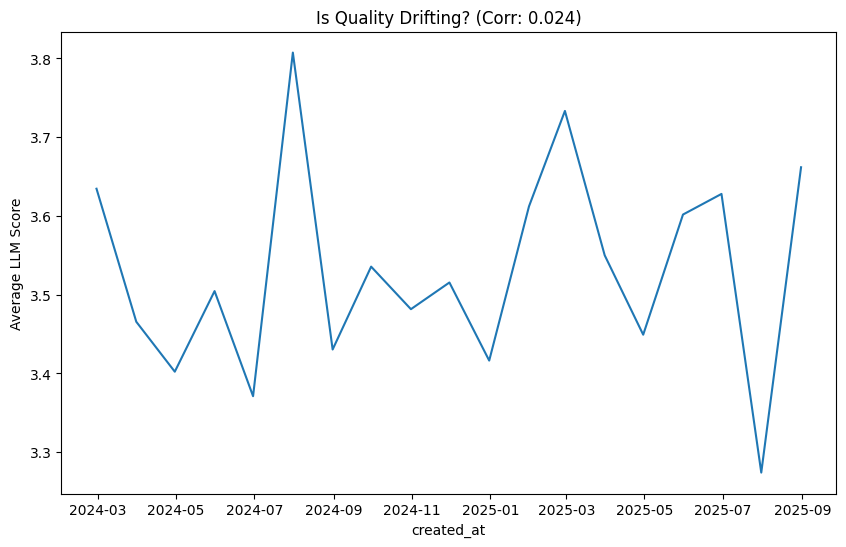

In [10]:
# 1. Check if Quality correlates with Time
# We use the 'days_since_start' we created earlier
import matplotlib.pyplot as plt
import seaborn as sns
quality_time_corr = subset_final_df[[
    'days_since_start', 'mean_rating']].corr().iloc[0, 1]

print(f"Correlation between Time and Quality: {quality_time_corr:.4f}")

# 2. Visualize the drift

plt.figure(figsize=(10, 6))
# Plot monthly average quality to reduce noise
monthly_quality = subset_final_df.set_index('created_at').resample('ME')[
    'mean_rating'].mean()

sns.lineplot(x=monthly_quality.index, y=monthly_quality.values)
plt.title(f"Is Quality Drifting? (Corr: {quality_time_corr:.3f})")
plt.ylabel("Average LLM Score")
plt.show()

## General

- Deals with zero applications

In [28]:
og_df_zero_apps = og_df[og_df.applicants_applications_count == 0]
og_df_zero_apps

,applicants_applications_count,content_types,deal_id,main_image,min_social_media_followers,deal_tags,live_since,created_at,updated_at,deleted_at,...,tags,gender,featured_image,company_id,test_nr_of_apps,update_at_date,diff,apps_after_7_days,apps_after_7_days_OLD,days_since_start
1,0,"[{'id': 21, 'name': 'Fashion', 'slug': 'Dress'}]",019689e5-f489-00c8-8c26-06b3ea0961a5,uploads/deals/019689e5-f54b-ffff-dbed-637e9d2a...,5000,None,2023-11-28 14:59:51.626780,2023-11-28 14:59:51.626780,2025-05-01 03:31:11.600095,NaT,...,None,None,None,None,0,2025-05-01,0,0,0.0,82
7,0,"[{'id': 19, 'name': 'Sport', 'slug': 'Soccer-B...",019689e4-306b-00c8-d98c-70210470c288,uploads/deals/019689e4-3146-ffff-e4a6-efb122b1...,2500,None,2024-12-21 13:36:47.610355,2024-12-21 13:36:47.610355,2025-05-01 03:29:15.743063,NaT,...,None,None,None,None,0,2025-05-01,0,0,0.0,471
20,0,"[{'id': 21, 'name': 'Fashion', 'slug': 'Dress'}]",0196cf30-3d9e-00c8-45de-a6091919cc67,,1500,None,NaT,2025-05-14 14:26:07.390204,2025-05-14 14:38:34.607315,2025-05-15 09:33:30.588079+00:00,...,None,None,None,None,0,2025-05-14,0,0,NaN,615
22,0,"[{'id': 41, 'name': 'Activities', 'slug': 'per...",019689e2-4ed5-00c8-4120-a08641f9f6f7,uploads/deals/019689e2-4ff4-ffff-5f8b-033c32b8...,5000,None,2024-05-02 09:27:34.909380,2024-05-02 09:27:34.909380,2025-05-01 03:27:12.709921,NaT,...,None,None,None,None,0,2025-05-01,0,0,4.0,237
23,0,"[{'id': 21, 'name': 'Fashion', 'slug': 'Dress'}]",0196cf35-c5d6-00c8-4d97-bbfef60b2cf5,,2500,None,NaT,2025-05-14 14:32:09.942486,2025-05-14 14:32:15.868080,2025-05-14 14:35:11.325650+00:00,...,None,None,None,None,0,2025-05-14,0,0,NaN,615
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5041,0,"[{'id': 41, 'name': 'Activities', 'slug': 'per...",019689e4-8d77-00c8-af2c-88afecf6d330,uploads/deals/019689e4-8e9b-ffff-f2dc-de9dc691...,2500,None,2025-02-05 10:50:49.679167,2025-02-05 10:50:49.679167,2025-10-28 10:51:10.763570,NaT,...,None,None,None,0199f1b1-a870-015e-9154-4fe289974050,0,2025-10-28,0,0,0.0,517
5068,0,"[{'id': 41, 'name': 'Activities', 'slug': 'per...",019689e4-9589-00c8-7dcb-d0bd27e9de7d,uploads/deals/019689e4-96ac-ffff-a035-6766138f...,50000,None,2025-04-27 09:08:03.830735,2025-04-27 09:08:03.830735,2025-10-28 10:50:03.356636,NaT,...,None,None,None,0199f1a2-caa1-015e-b4db-2edf3b482672,0,2025-10-28,0,0,3.0,597
5098,0,"[{'id': 39, 'name': 'Experiences', 'slug': 'Te...",019689e4-a9d4-00c8-6d70-59ec50167ab7,uploads/deals/019689e4-aa38-ffff-e781-3a523780...,5000,None,2024-03-15 13:45:49.561715,2024-03-15 13:45:49.561715,2025-10-28 10:54:48.369215,NaT,...,None,None,None,0199f1cd-8862-015e-ca76-0be502d21b6a,0,2025-10-28,0,0,0.0,190
5108,0,"[{'id': 23, 'name': 'Food', 'slug': 'Pizza'}]",0198324e-635d-00c8-7d1d-bbb0b902b0d9,,10000,None,NaT,2025-07-22 13:24:14.813323,2025-10-28 11:04:12.121141,NaT,...,None,None,None,0199f18e-af17-015e-23aa-c780e5c4a2b8,0,2025-10-28,0,0,NaN,684


- Deals with positive number of applications but no applications after 7 days

In [29]:
og_df[(og_df['apps_after_7_days'] == 0) & (
    og_df['applicants_applications_count'] > 0)]

,applicants_applications_count,content_types,deal_id,main_image,min_social_media_followers,deal_tags,live_since,created_at,updated_at,deleted_at,...,tags,gender,featured_image,company_id,test_nr_of_apps,update_at_date,diff,apps_after_7_days,apps_after_7_days_OLD,days_since_start
24,65,"[{'id': 23, 'name': 'Food', 'slug': 'Pizza'}, ...",019689e5-c8c2-00c8-79f3-9992362edeea,uploads/deals/019689e5-c976-ffff-edd8-529b3e62...,5000,None,NaT,2023-11-22 12:13:25.712323,2025-05-01 03:31:00.674606,2024-02-10 14:35:49.163784+00:00,...,None,None,None,None,65,2025-05-01,0,0,NaN,76
25,56,"[{'id': 23, 'name': 'Food', 'slug': 'Pizza'}]",019689e4-bde0-00c8-dcce-bb7de653145b,uploads/deals/019689e4-be81-ffff-4174-cd8a5c2d...,10000,None,2025-01-13 15:37:11.226833,2025-01-13 15:37:11.226833,2025-05-22 04:00:16.868866,NaT,...,None,None,None,None,56,2025-05-22,0,0,0.0,494
31,18,"[{'id': 41, 'name': 'Activities', 'slug': 'per...",0196f22e-9224-00c8-1f18-378560b58a42,uploads/deals/0196f22a-eae6-ffff-e2f6-8a112033...,1500,None,2025-05-21 09:31:00.752564,2025-05-21 09:31:00.516748,2025-10-28 10:52:44.677317,NaT,...,None,None,None,0199f1d9-ba9c-015e-98dd-31cc262c0e04,18,2025-10-28,0,0,0.0,621
33,6,"[{'id': 23, 'name': 'Food', 'slug': 'Pizza'}]",019689e3-770b-00c8-d2ee-83252084a97a,uploads/deals/019689e3-77aa-ffff-9af7-e4cde670...,2500,None,NaT,2024-02-16 13:13:22.821687,2025-05-01 03:28:28.371244,2024-02-24 14:08:58.711124+00:00,...,None,None,None,None,6,2025-05-01,0,0,NaN,162
44,148,"[{'id': 41, 'name': 'Activities', 'slug': 'per...",019689e3-287d-00c8-258d-b4e8df65b7a5,uploads/deals/019689e3-294c-ffff-313b-5c2680e5...,5000,None,2023-09-28 12:34:50.532202,2023-09-28 12:34:50.532202,2025-10-28 10:56:13.372705,NaT,...,None,None,None,0199f1d2-2345-015e-d386-0d22efe5edcf,148,2025-10-28,0,0,0.0,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4971,3,"[{'id': 41, 'name': 'Activities', 'slug': 'per...",0196d4a5-62a4-00c8-afe1-0e592c281122,uploads/deals/0196d4a4-a3e1-ffff-f2c5-d2aebc1c...,10000,None,2025-05-15 15:52:10.852458,2025-05-15 15:52:10.660506,2025-06-15 21:59:22.317427,NaT,...,None,None,None,None,3,2025-06-15,0,0,6.0,616
4993,1,"[{'id': 29, 'name': 'UGC', 'slug': 'Film-Strip...",0196ceae-4334-00c8-65d6-7fb556b9ba6f,uploads/deals/0196ceae-1f69-ffff-955d-61eb09b2...,5000,None,2025-05-14 12:04:09.257984,2025-05-14 12:04:09.140652,2025-05-14 12:04:09.258113,NaT,...,None,None,None,None,1,2025-05-14,0,0,37.0,615
5006,6,"[{'id': 25, 'name': 'Cooking', 'slug': 'Cookin...",019689e4-8482-00c8-60fa-3cb52ac85ff5,uploads/deals/019689e4-8597-ffff-9779-60501bb9...,2500,None,2025-05-20 11:35:10.937802,2025-04-25 14:03:19.480448,2025-10-28 10:49:41.201605,NaT,...,None,None,None,0199f19e-56a2-015e-a4aa-5d54b2c701bb,6,2025-10-28,0,0,13.0,596
5019,31,"[{'id': 39, 'name': 'Experiences', 'slug': 'Te...",019689e3-2d2a-00c8-8b96-27c693c7ab51,uploads/deals/019689e3-2d91-ffff-6b6c-b8dfc7c8...,5000,None,2024-02-06 10:29:13.139738,2024-02-06 10:29:13.139738,2025-05-01 03:28:09.341890,NaT,...,None,None,None,None,31,2025-05-01,0,0,28.0,152


- Within-company variance

In [29]:
text_stats = og_df.groupby('partner_id')['apps_after_7_days'].agg([
    'count', 'mean', 'var', 'std'])
text_stats

,count,mean,var,std
partner_id,,,,
1,6,0.000000,0.000000,0.000000
2,1,0.000000,NaN,NaN
3,6,0.166667,0.166667,0.408248
4,13,18.307692,1863.730769,43.170948
5,2,0.000000,0.000000,0.000000
...,...,...,...,...
3460,1,0.000000,NaN,NaN
3468,1,0.000000,NaN,NaN
3471,1,0.000000,NaN,NaN


In [30]:
# 1. Group by identical deal text
# We calculate count (to find dupes), mean, and variance for each unique text
text_stats = og_df.groupby('deal_text')['apps_after_7_days'].agg([
    'count', 'mean', 'var', 'std'])

# 2. Filter: We only care about texts that were posted more than once
# We also drop NaNs in variance (which happen if count < 2)
duplicates = text_stats[text_stats['count'] > 1].dropna()

print(f"Found {len(duplicates)} unique texts that were posted multiple times.")
print(
    f"Total observations involved in duplicates: {duplicates['count'].sum()}")

# 3. Calculate the "Pure Error" vs "Total Variance"
# Pure Error = The average variance *within* these identical groups
pure_error_variance = duplicates['var'].mean()

# Total Variance = The variance of the entire dataset (ignoring text identity)
total_variance = og_df['apps_after_7_days'].var()

# 4. The "Unexplainable" Ratio
noise_ratio = pure_error_variance / total_variance

print(f"\n--- Variance Analysis ---")
print(f"Total Dataset Variance:   {total_variance:.2f}")
print(f"Variance within Reposts:  {pure_error_variance:.2f} (Pure Error)")
print(f"Noise Ratio:              {noise_ratio:.2%}")

# 5. Interpretation
if noise_ratio > 0.5:
    print("\n⚠️ CRITICAL: Over 50% of the variation in applications has nothing to do with the text.")
    print("Even if you trained a perfect AI, it could only explain <50% of the results.")
else:
    print(
        f"\n✅ Good News: Only {noise_ratio:.1%} of variance is random noise.")
    print("There is still plenty of signal for the model to learn.")

Found 293 unique texts that were posted multiple times.
Total observations involved in duplicates: 788

--- Variance Analysis ---
Total Dataset Variance:   268.49
Variance within Reposts:  131.02 (Pure Error)
Noise Ratio:              48.80%

✅ Good News: Only 48.8% of variance is random noise.
There is still plenty of signal for the model to learn.


- Partners with many deals

In [32]:
partner_count = og_df.partner_id.value_counts()
partner_count

# og_df = pd.merge(og_df, partner_count, on = 'partner_id')
# partner_count

partner_id
85      73
461     73
6       38
871     30
401     27
        ..
1994     1
2002     1
1692     1
2193     1
1051     1
Name: count, Length: 1635, dtype: int64

In [33]:
# Proportion of observations that come from partners that have more than 10 total deals

partner_count[partner_count > 10].sum() / partner_count.sum()

np.float64(0.21829924650161464)

- Social requirement type

In [13]:
og_df.social_requirement_type_id.value_counts()

social_requirement_type_id
3.0     1860
2.0     1337
4.0      610
1.0      519
5.0      165
6.0       86
34.0      54
Name: count, dtype: int64

In [ ]:
og_df.groupby('social_requirement_type_id')[
    'applicants_applications_count'].agg('mean')

social_requirement_type_id
1.0     23.736031
2.0     39.523560
3.0     30.517204
4.0     22.562295
5.0      8.345455
6.0     30.755814
34.0     2.518519
Name: applicants_applications_count, dtype: float64

In [18]:
og_df[og_df.partner_id == 4]

,applicants_applications_count,content_types,deal_id,main_image,min_social_media_followers,deal_tags,live_since,created_at,updated_at,deleted_at,...,legacy_id,tags,gender,featured_image,company_id,test_nr_of_apps,update_at_date,diff,apps_after_7_days,apps_after_7_days_OLD
505,1,"[{'id': 41, 'name': 'Activities', 'slug': 'per...",019689e3-5f87-00c8-99d5-2d1db6204f32,uploads/deals/019689e3-603a-ffff-d2cd-148f7533...,2500,None,2023-10-02 14:07:43.198076,2023-10-02 14:07:43.198076,2025-05-01 03:28:22.309643,NaT,...,204.0,None,None,None,None,1,2025-05-01,0,0,0.0
944,326,"[{'id': 41, 'name': 'Activities', 'slug': 'per...",019689e3-b5d1-00c8-b43f-212bb3732b1c,uploads/deals/019689e3-b636-ffff-5668-6e78d27e...,50000,None,2023-10-06 11:32:11.616933,2023-10-06 11:32:11.616933,2025-05-01 03:28:44.208848,NaT,...,242.0,None,None,None,None,326,2025-05-01,0,19,0.0
1520,0,"[{'id': 40, 'name': 'Drinks', 'slug': 'Champag...",019689e4-55b8-00c8-e758-36a3fe17d11d,uploads/deals/019689e4-56ae-ffff-0d87-9a008138...,5000,None,NaT,2024-03-11 09:38:29.167985,2025-05-01 03:29:26.120218,2024-03-11 09:45:51.483595+00:00,...,772.0,None,None,None,None,0,2025-05-01,0,0,16.0
1779,144,"[{'id': 41, 'name': 'Activities', 'slug': 'per...",019689e2-9b0d-00c8-db74-83e494e323cb,uploads/deals/019689e2-9b65-ffff-c7ff-8c5e28b5...,2500,None,2024-01-12 11:01:17.534158,2024-01-12 11:01:17.534158,2025-10-28 10:56:06.614862,NaT,...,574.0,None,None,None,0199f1d3-e270-015e-e659-f097472753a4,144,2025-10-28,0,144,0.0
1921,0,"[{'id': 40, 'name': 'Drinks', 'slug': 'Champag...",019689e4-efda-00c8-0ecc-02a2a25cdfba,uploads/deals/019689e4-f18b-ffff-54ed-01dc63cf...,2500,None,NaT,2024-07-08 16:44:41.926613,2025-05-01 03:30:06.205992,2024-07-08 16:45:39.090249+00:00,...,1272.0,None,None,None,None,0,2025-05-01,0,0,1.0
2838,118,"[{'id': 39, 'name': 'Experiences', 'slug': 'Te...",019689e3-5128-00c8-994a-73657a1b0ca4,uploads/deals/019689e3-51c7-ffff-0a34-807e23ca...,50000,None,2023-10-02 12:52:21.704136,2023-10-02 12:52:21.704136,2025-10-28 10:56:09.195922,NaT,...,199.0,None,None,None,0199f1d3-e270-015e-e659-f097472753a4,118,2025-10-28,0,0,6.0
2874,0,"[{'id': 39, 'name': 'Experiences', 'slug': 'Te...",019689e3-53e9-00c8-3359-bf323786e75e,uploads/deals/019689e3-5471-ffff-7012-268bdc8f...,2500,None,2023-10-02 13:12:01.216469,2023-10-02 13:12:01.216469,2025-10-28 10:56:09.405883,NaT,...,200.0,None,None,None,0199f1d3-e270-015e-e659-f097472753a4,0,2025-10-28,0,0,NaN
2898,0,"[{'id': 33, 'name': 'Entertainment', 'slug': '...",019689e5-dbeb-00c8-229e-10de82cf0064,uploads/deals/019689e5-e07d-ffff-d34e-4e25c628...,2500,None,NaT,2024-10-24 09:38:49.844412,2025-05-01 03:31:06.277996,2024-10-24 09:46:10.041301+00:00,...,1965.0,None,None,None,None,0,2025-05-01,0,0,NaN
2906,0,"[{'id': 39, 'name': 'Experiences', 'slug': 'Te...",019689e2-3189-00c8-68db-cc5381833f3d,uploads/deals/019689e2-3335-ffff-f63e-175640fe...,5000,None,NaT,2024-05-01 13:20:43.146930,2025-05-01 03:27:05.899254,2024-05-02 09:31:05.213134+00:00,...,1056.0,None,None,None,None,0,2025-05-01,0,0,5.0
2923,0,"[{'id': 40, 'name': 'Drinks', 'slug': 'Champag...",019689e2-c297-00c8-c378-191d3b5dff3b,uploads/deals/019689e2-c331-ffff-c0eb-209f0e7c...,2500,None,NaT,2024-01-19 14:41:56.632128,2025-05-01 03:27:42.095928,2024-01-19 14:42:00.450313+00:00,...,589.0,None,None,None,None,0,2025-05-01,0,0,NaN


In [19]:
og_df[og_df['social_requirement_type_id'] == 6]

,applicants_applications_count,content_types,deal_id,main_image,min_social_media_followers,deal_tags,live_since,created_at,updated_at,deleted_at,...,legacy_id,tags,gender,featured_image,company_id,test_nr_of_apps,update_at_date,diff,apps_after_7_days,apps_after_7_days_OLD
26,6,"[{'id': 23, 'name': 'Food', 'slug': 'Pizza'}, ...",0198608d-899b-00c8-d331-75d1dabc8a2c,uploads/deals/0198608c-b810-ffff-ba12-ffa0228c...,50000,None,2025-07-31 12:55:45.445527,2025-07-31 12:55:45.307628,2025-10-28 10:50:05.414297,NaT,...,NaN,None,None,None,0199f1a3-3d16-015e-52ca-006b924bdcfc,6,2025-10-28,0,5,5.0
121,25,"[{'id': 39, 'name': 'Experiences', 'slug': 'Te...",019689e5-95a1-00c8-9b7c-153878e259f6,uploads/deals/019689e5-9657-ffff-4b9f-747eb6b9...,50000,None,2023-11-15 11:54:31.853721,2023-11-15 11:54:31.853721,2025-10-28 10:55:42.620217,NaT,...,450.0,None,None,None,0199f1d4-9856-015e-5435-d593bd80df8f,25,2025-10-28,0,15,23.0
174,7,"[{'id': 37, 'name': 'Luxury', 'slug': 'Sketch-...",0196d494-dc4a-00c8-e58e-1a638ebcfdae,uploads/deals/0196d491-3f06-ffff-57c0-8d3054b9...,50000,None,2025-05-15 15:34:07.850723,2025-05-15 15:34:07.690325,2025-08-18 04:00:11.142413,NaT,...,NaN,None,None,None,None,7,2025-08-18,0,3,3.0
229,0,"[{'id': 33, 'name': 'Entertainment', 'slug': '...",019689e2-639f-00c8-8cc0-63a1af7916c4,uploads/deals/019689e2-64ce-ffff-b723-98ee5492...,50000,None,2023-12-20 15:52:33.629474,2023-12-20 15:52:33.629474,2025-05-01 03:27:17.974751,NaT,...,545.0,None,None,None,None,0,2025-05-01,0,0,0.0
283,0,"[{'id': 41, 'name': 'Activities', 'slug': 'per...",019689e2-7945-00c8-a300-5446558001e1,uploads/deals/019689e2-79e6-ffff-d2ee-2998d00d...,50000,None,2025-02-27 15:55:25.226241,2025-02-27 15:55:25.226241,2025-05-01 03:27:23.210618,NaT,...,3553.0,None,None,None,None,0,2025-05-01,0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4548,39,"[{'id': 31, 'name': 'Lifestyle', 'slug': 'Mart...",019689e3-0ce5-00c8-3006-b0f798dbdde0,uploads/deals/019689e3-0e2b-ffff-5f65-d0249c67...,50000,None,2025-04-08 14:48:07.695676,2025-04-08 14:48:07.695676,2025-05-01 03:28:01.376729,NaT,...,4105.0,None,None,None,None,39,2025-05-01,0,25,0.0
4761,73,"[{'id': 37, 'name': 'Luxury', 'slug': 'Sketch-...",01976412-1851-00c8-07df-59a256bdda52,uploads/deals/01976411-3125-ffff-dd39-a7644dfe...,50000,None,2025-06-12 12:16:37.062524,2025-06-12 12:16:36.945143,2025-09-14 04:00:04.933481,NaT,...,NaN,None,None,None,None,73,2025-09-14,0,51,8.0
4829,1,"[{'id': 37, 'name': 'Luxury', 'slug': 'Sketch-...",0198a841-9305-00c8-cf36-32f2d774ed17,uploads/deals/0198a83f-c79f-ffff-91b9-22f4cb81...,50000,None,2025-08-14 11:05:26.728556,2025-08-14 11:05:26.533184,2025-09-14 04:00:05.630671,NaT,...,NaN,None,None,None,None,1,2025-09-14,0,1,2.0
5068,0,"[{'id': 41, 'name': 'Activities', 'slug': 'per...",019689e4-9589-00c8-7dcb-d0bd27e9de7d,uploads/deals/019689e4-96ac-ffff-a035-6766138f...,50000,None,2025-04-27 09:08:03.830735,2025-04-27 09:08:03.830735,2025-10-28 10:50:03.356636,NaT,...,4362.0,None,None,None,0199f1a2-caa1-015e-b4db-2edf3b482672,0,2025-10-28,0,0,3.0


In [38]:
weekly_stats

,Deals_Posted,Total_Apps,Avg_Apps,Median_Apps
created_at,,,,
2023-09-11,8,1,0.125000,0.0
2023-09-18,12,157,13.083333,1.0
2023-09-25,12,26,2.166667,0.5
2023-10-02,19,112,5.894737,0.0
2023-10-09,31,162,5.225806,0.0
...,...,...,...,...
2025-09-22,151,1421,9.410596,2.0
2025-09-29,93,936,10.064516,4.0
2025-10-06,74,1088,14.702703,4.0
